# 데이터사이언스 기말 프로젝트 - 5팀

---
## 프로젝트 주제

**도서관 자리는 항상 부족한데, 왜 빈자리가 보일까?**

도서관 열람실 데이터를 활용해 좌석 선호도와 이용 패턴을 분석하고, 실제로 선택 가능한 좌석을 늘리는 공간의 효율화 방안을 제안하고자 합니다.

---
## 필요한 데이터


- 문제의식: **도서관 좌석 이용 비효율**  "자리는 부족한데, 빈자리는 왜 보이는가?"
- 좌석 이용의 핵심 원인 변수: **좌석 위치, 주변 환경, 이용 시간, 장시간 배정 방식,심리적 선호**
- 목표: 단순한 좌석 증설 대신 기존 공간의 효율적 활용 방안을 데이터로 검증
- 수집 데이터: **공간 구조 / 시간대별 좌석 이용 로그 / 이용자 설문**
- 다중 데이터 (양적,질적 데이터) 활용 이유: 이용 로그만으로는 좌석 선택,기피 이유 설명 불가 -> 물리적 배치 + 이용자 인식 병행 분석

---
## 데이터 종류 소개 및 수집 방법

**1. 열람실 배치도 데이터 (`layout_data.json`)**

- 구성: **좌석·문·창문·벽·기둥·통로 등 공간 요소를 좌표값으로 구조화**
- 수집: **도서관 배치도 + 제1열람실 직접 실측 → 좌표 공간에 매핑**
- 변수: x/y 위치, 너비, 높이, 회전값, 요소 유형
- 활용: 좌석별 공간 특성 수치화 (출입구·창가·기둥·통행량과의 관계) → 선호도 분석의 설명 변수
- 처리: Google Drive → `gdown` 다운로드 → JSON을 `pandas` 데이터프레임으로 변환


**2. 열람실 이용 데이터 (`library_seats.csv`)**

- 구성: **10분 단위 좌석 점유 스냅샷 시계열 데이터**
- 수집: **매일 오전 5시 ~ 익일 오전 1시, 자동화 스크립트로 한국외대 도서관 홈페이지에서 크롤링**
- 변수: 좌석 번호, 점유 여부, 활성화 여부, 이용 시간 관련 정보
- 전처리: `seats_data` 컬럼의 JSON 문자열 → 좌석 단위로 파싱
- 활용: 시간대별 점유율, 좌석별 누적 이용률, 과이용·저이용 좌석 식별, 장시간 이용 패턴 분석
- 처리: Google Drive → 노트북에서 다운로드 후 로드


**3. 설문 데이터**

- 구성: **이용자의 좌석 선택/기피 이유 파악을 위한 설문**
- 수집 항목: **좌석 부족 체감 빈도, 좌석 선택 기준, 빈자리 미사용 이유, 환경 요소별 영향도 (콘센트·소음·출입구 거리·창가·조명·냉난방·통행량·프라이버시)**
- 활용: 이용 로그의 정량 패턴("어떤 좌석이 덜 쓰이는지")을 설문으로 정성 해석("왜 덜 쓰이는지") 함으로써 공간 효율화 방안 도출

---
## 데이터 전처리

**필요한 모듈 설치 및 한글 폰트 설정**

In [ ]:
# 필요한 모듈 설치 및 한글 폰트 설정 (Colab/Windows 공통)
import importlib.util
import os
import shutil
import subprocess
import sys

required_packages = {
    'gdown': 'gdown',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'scipy': 'scipy',
    'seaborn': 'seaborn',
}

for import_name, package_name in required_packages.items():
    if importlib.util.find_spec(import_name) is None:
        subprocess.run(
            [sys.executable, '-m', 'pip', 'install', '-q', package_name],
            check=True
        )

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# Colab/Linux에서는 NanumGothic을 설치하고, 로컬 Windows에서는 맑은 고딕을 사용합니다.
if shutil.which('apt-get'):
    subprocess.run(
        ['apt-get', 'install', '-y', '-q', 'fonts-nanum'],
        capture_output=True,
        check=False
    )

font_candidates = [
    '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    'C:/Windows/Fonts/malgun.ttf',
    'C:/Windows/Fonts/malgunbd.ttf',
    '/System/Library/Fonts/AppleGothic.ttf',
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
]

font_path = next((path for path in font_candidates if os.path.exists(path)), None)

if font_path:
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    print(f'한글 폰트 설정 완료: {font_name}')
else:
    print('한글 폰트를 찾지 못했습니다.')

plt.rcParams['axes.unicode_minus'] = False
print('필요한 모듈 확인 완료')

한글 폰트 설정 완료: NanumGothic
필요한 모듈 확인 완료


**열람실 배치도 데이터 다운로드 및 확인**

In [ ]:
import gdown
import json
import pandas as pd
from pathlib import Path

file_id = '1p6W2whVCjKwSZtVWn6B70C-1CWcoMQax'
data_dir = Path('/content') if Path('/content').exists() else Path('.')
output_path_json = str(data_dir / 'layout_data.json')

gdown.download(
    f'https://drive.google.com/uc?id={file_id}',
    output_path_json,
    quiet=False
)

print('배치도 데이터 다운로드 완료')
print(f'저장 위치: {output_path_json}')

# JSON 파일 로드
with open(output_path_json, 'r', encoding='utf-8') as f:
    layout_data = json.load(f)

df_layout = pd.json_normalize(layout_data)

print("배치도 데이터 DataFrame의 형태:", df_layout.shape)
print("배치도 데이터 DataFrame (상위 3행):")
display(df_layout.head(3))

print("배치도 데이터 DataFrame의 컬럼 타입:")
display(df_layout.dtypes)

Downloading...
From: https://drive.google.com/uc?id=1p6W2whVCjKwSZtVWn6B70C-1CWcoMQax
To: /content/layout_data.json
100%|██████████| 189k/189k [00:00<00:00, 40.6MB/s]

배치도 데이터 다운로드 완료
저장 위치: /content/layout_data.json
배치도 데이터 DataFrame의 형태: (1, 11)
배치도 데이터 DataFrame (상위 3행):


,elements,seat,motion,door,window,pillar,wall,room.x,room.y,room.w,room.h
0,"[{'category': 'wall', 'x': 586.3854370117188, ...","[{'category': 'seat', 'x': 32.38543701171875, ...","[{'category': 'motion', 'x': 546.3854370117188...","[{'category': 'door', 'x': 884.3854370117188, ...","[{'category': 'window', 'x': 1839.385437011718...","[{'category': 'pillar', 'x': 111.3854370117187...","[{'category': 'wall', 'x': 586.3854370117188, ...",61.614563,275,1882,795


배치도 데이터 DataFrame의 컬럼 타입:


,0
elements,object
seat,object
motion,object
door,object
window,object
pillar,object
wall,object
room.x,float64
room.y,int64
room.w,int64


**열람실 배치도 데이터 시각화**

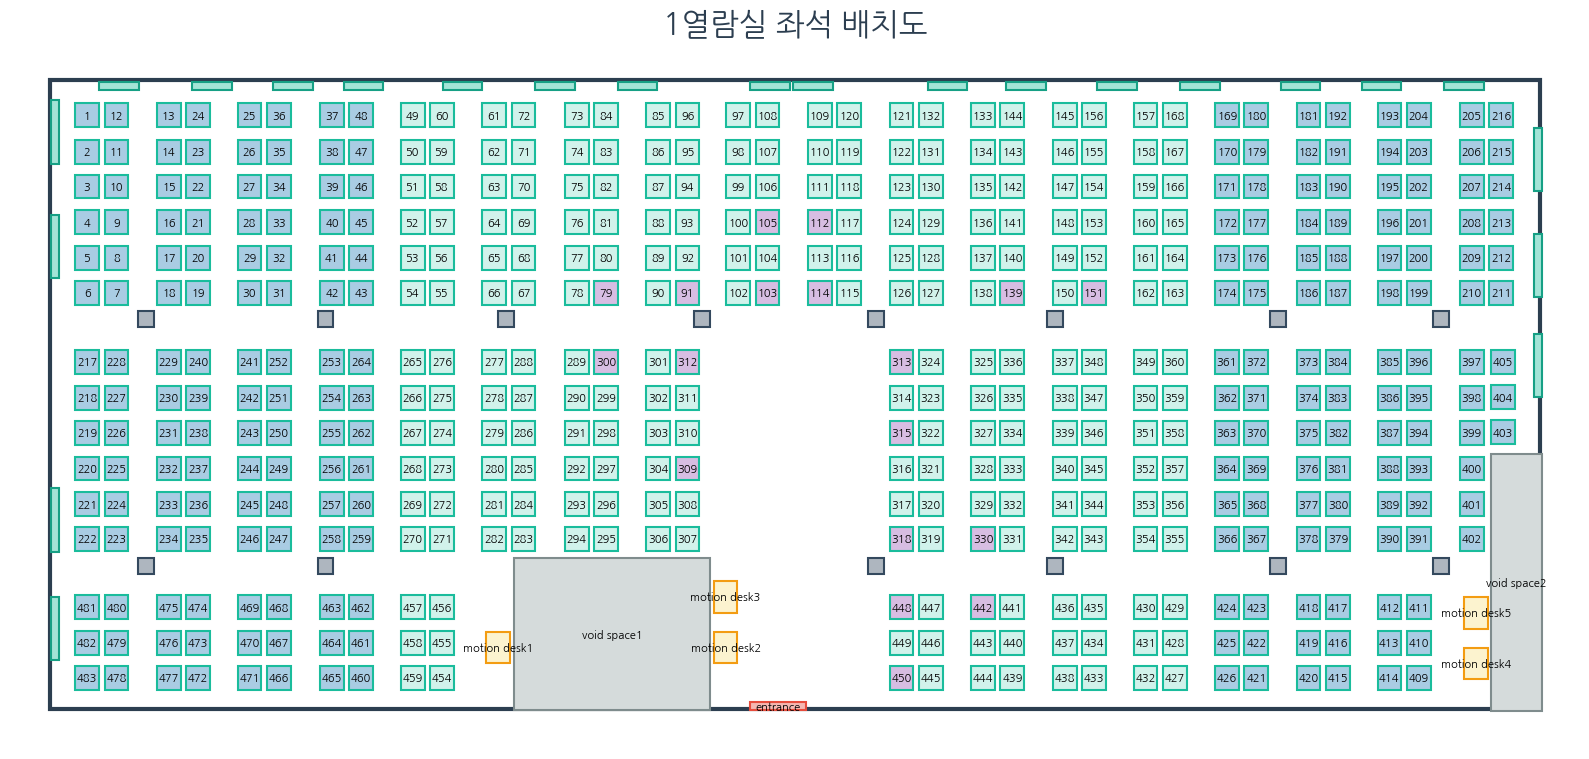

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import os

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

def draw_blueprint():
    # `output_path_json` 변수는 이전 셀에서 정의
    global output_path_json, layout_data

    if not 'output_path_json' in globals() or not os.path.exists(output_path_json):
        print(f"데이터 파일이 없습니다: {output_path_json}. 이전 셀을 먼저 실행하여 파일을 다운로드해주세요.")
        return

    # 이미 로드된 layout_data를 사용
    # layout_data가 현재 딕셔너리 형태이므로 그대로 사용
    if not layout_data or not isinstance(layout_data, dict):
        print("로드된 배치도 데이터가 비어있거나 예상한 형식이 아닙니다.")
        return

    data = layout_data # 로드된 딕셔너리를 그대로 사용

    # 열람실 영역 정보
    room = data.get('room', {})
    rw = room.get('w', 1000)
    rh = room.get('h', 800)

    # 전체 요소 리스트
    elements = data.get('elements', [])

    fig, ax = plt.subplots(figsize=(16, 10))

    # 1. 열람실 영역 그리기 (원점 0,0 기준)
    ax.add_patch(patches.Rectangle((0, 0), rw, rh, linewidth=3, edgecolor='#2c3e50', facecolor='none', zorder=1))

    # 2. 모든 객체 그리기 (데이터의 x, y를 그대로 사용)
    colors = {
        'seat': '#d1f2eb', 'motion': '#fcf3cf', 'door': '#f5b7b1',
        'window': '#a3e4d7', 'pillar': '#aeb6bf', 'wall': '#d5dbdb'
    }
    edge_colors = {
        'seat': '#1abc9c', 'motion': '#f39c12', 'door': '#e74c3c',
        'window': '#16a085', 'pillar': '#34495e', 'wall': '#7f8c8d'
    }

    for el in elements:
        cat = el.get('category')
        x, y, w, h = el.get('x', 0), el.get('y', 0), el.get('w', 30), el.get('h', 30)
        r = el.get('r', 0)
        item_id = str(el.get('id', ''))

        # 회전 중심점
        cx, cy = x + w/2, y + h/2
        fc = colors.get(cat, '#eeeeee')
        ec = edge_colors.get(cat, '#333333')

        if cat == 'seat':
            s_type = el.get('type', 'normal')
            if s_type == 'cubicle': fc = '#a9cce3'
            elif s_type == 'disabled': fc = '#d7bde2'

        rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor=ec, facecolor=fc, zorder=2)
        # 회전 변환 적용
        t = transforms.Affine2D().rotate_deg_around(cx, cy, r) + ax.transData
        rect.set_transform(t)
        ax.add_patch(rect)

        # ID 텍스트 (회전 안 함)
        if item_id:
            ax.text(cx, cy, item_id, ha='center', va='center', fontsize=8, fontweight='bold', zorder=3)

    # 축 설정
    ax.set_xlim(-50, rw + 50)
    ax.set_ylim(-50, rh + 50)
    ax.set_aspect('equal')
    ax.invert_yaxis() # 그래픽 좌표계 (Y축 아래로 증가)
    ax.axis('off')

    plt.title("1열람실 좌석 배치도", fontsize=22, fontweight='bold', pad=5, color='#2c3e50')
    plt.tight_layout()
    plt.show()

# 배치도 그리기 함수 호출
draw_blueprint()

**배치도 색상 범례**

| 색상 | 의미 |
|---|---|
| 연한 민트색 (`#d1f2eb`) | 개방형 좌석 (seat)
| 하늘색 (`#a9cce3`) | 칸막이 좌석 (cubicle) |
| 보라색 (`#d7bde2`) | 장애인 좌석 (disabled)
| 연노랑색 (`#fcf3cf`) | 모션데스크 (motion)
| 연빨강색 (`#f5b7b1`) | 출입문 (door)
| 민트색 (`#a3e4d7`) | 창문 (window) |
| 회색 (`#aeb6bf`) | 기둥 (pillar)
| 연회색 (`#d5dbdb`) | 벽/공간 (wall, void space)
| 진한 남색 테두리 (`#2c3e50`) | 열람실 외곽

**열람실 이용 데이터 CSV 다운로드 및 확인**

In [ ]:
import gdown
from pathlib import Path
import pandas as pd

# file_id = '1o_5hzjd4U928q32zqBUJYmTC5GPjnITx'
file_id = '18RLddfYFqN_KGqu79gjjlUvv5aVtmJaq'
data_dir = Path('/content') if Path('/content').exists() else Path('.')
output_path = str(data_dir / 'library_seats.csv')

gdown.download(
    f'https://drive.google.com/uc?id={file_id}',
    output_path,
    quiet=False
)

print('열람실 이용 데이터 다운로드 완료')
print(f'저장 위치: {output_path}\n')

df = pd.read_csv(output_path)
display(df.shape)
display(df.head(3))
display(df.dtypes)

Downloading...
From (original): https://drive.google.com/uc?id=18RLddfYFqN_KGqu79gjjlUvv5aVtmJaq
From (redirected): https://drive.google.com/uc?id=18RLddfYFqN_KGqu79gjjlUvv5aVtmJaq&confirm=t&uuid=d5d711d3-7b65-40f2-baa3-53cd50636c52
To: /content/library_seats.csv
100%|██████████| 617M/617M [00:08<00:00, 76.3MB/s]


열람실 이용 데이터 다운로드 완료
저장 위치: /content/library_seats.csv



(5242, 4)

,id,collected_at,room_name,seats_data
0,14,2026-04-11 05:00:00+09,1열람실,"[{""id"": 829, ""code"": ""1"", ""room"": {""id"": 6, ""n..."
1,15,2026-04-11 05:10:00+09,1열람실,"[{""id"": 829, ""code"": ""1"", ""room"": {""id"": 6, ""n..."
2,16,2026-04-11 05:20:00+09,1열람실,"[{""id"": 829, ""code"": ""1"", ""room"": {""id"": 6, ""n..."


,0
id,int64
collected_at,object
room_name,object
seats_data,object


**열람실 이용 데이터의 seats_data JSON 컬럼 파싱**

seats_data 컬럼을 JSON 문자열로 수집-> 각 좌석 정보 풀어서 사용하기 좋게 파이썬 리스트로 파싱

**seats_data 주요 컬럼**

| 컬럼명                 | 설명                 |
| ------------------- | ------------------ |
| code                | 좌석 번호 (1, 2, 3...) |
| isActive            | 좌석 활성화 여부          |
| isOccupied          | 현재 점유 여부           |
| isReservable        | 예약 가능 여부           |
| chargeTime          | 이용 시간 (분)          |
| remainingTime       | 남은 시간 (분)          |
| room.id / room.name | 열람실 정보             |

In [ ]:
import json
import ast

# JSON 문자열에서 파이썬 리스트로 파싱
def parse_seats(s):
    try:
        return json.loads(s)
    except Exception:
        try:
            return ast.literal_eval(s)
        except Exception:
            return []

df['seats_parsed'] = df['seats_data'].apply(parse_seats)

# 각 행의 좌석 리스트를 개별 행으로 펼치기
df_seats = df[['id', 'collected_at', 'room_name', 'seats_parsed']].explode('seats_parsed').reset_index(drop=True)

# 딕셔너리 컬럼을 개별 컬럼으로 정규화
seats_norm = pd.json_normalize(df_seats['seats_parsed'])

# 원본 컬럼과 합치기
df_final = pd.concat([
    df_seats[['id', 'collected_at', 'room_name']].reset_index(drop=True),
    seats_norm.reset_index(drop=True)
], axis=1)

# room 컬럼 정리 (중첩 딕셔너리에서 이름만 추출)
if 'room.name' in df_final.columns:
    df_final = df_final.drop(columns=['room'], errors='ignore')

display(df_final.shape)
display(df_final.head(3))
display(df_final.columns.tolist())

(2531886, 16)

,id,collected_at,room_name,id,code,isActive,timeLine,chargeTime,isOccupied,isReservable,remainingTime,room.id,room.name,seatChargeState,seatType.id,seatType.name
0,14,2026-04-11 05:00:00+09,1열람실,829,1,False,None,0,False,False,0,6,1열람실,NaN,NaN,NaN
1,14,2026-04-11 05:00:00+09,1열람실,830,2,False,None,0,False,False,0,6,1열람실,NaN,NaN,NaN
2,14,2026-04-11 05:00:00+09,1열람실,831,3,True,None,960,True,False,141,6,1열람실,NaN,NaN,NaN


['id',
 'collected_at',
 'room_name',
 'id',
 'code',
 'isActive',
 'timeLine',
 'chargeTime',
 'isOccupied',
 'isReservable',
 'remainingTime',
 'room.id',
 'room.name',
 'seatChargeState',
 'seatType.id',
 'seatType.name']

**공통 전처리**

분석에 공통으로 사용할 `df_seats` 데이터프레임 구성

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from itertools import combinations
import os

# df_final로부터 df_seats 구성
# 기존 전처리 셀에서 생성된 df_final 활용
inactive_seats = df_final[df_final['isActive'] == False]['code'].unique()
df_seats = df_final[~df_final['code'].isin(inactive_seats)].copy()
df_seats = df_seats[df_seats['isActive'] == True]

# collected_at → datetime (KST)
df_seats['collected_at'] = (
    pd.to_datetime(df_seats['collected_at'], utc=True)
    .dt.tz_convert('Asia/Seoul')
    .dt.tz_localize(None)
)

# 편의 컬럼 추가
df_seats['hour']     = df_seats['collected_at'].dt.hour
df_seats['code_int'] = pd.to_numeric(df_seats['code'], errors='coerce')

# 시간대 레이블 함수
PERIOD_ORDER = ['새벽(1-5시)', '오전(5-12시)', '오후(12-19시)', '저녁(19-익일1시)']

def label_period(h):
    # 설문 시간대 기준: 새벽 1-5시, 오전 5-12시, 오후 12-19시, 저녁 19-익일 1시
    if 1 <= h < 5:
        return '새벽(1-5시)'
    elif 5 <= h < 12:
        return '오전(5-12시)'
    elif 12 <= h < 19:
        return '오후(12-19시)'
    else:
        return '저녁(19-익일1시)'

df_seats['period'] = df_seats['hour'].apply(label_period)

total_snaps = df_seats['collected_at'].nunique()
print(f'활성 좌석 레코드: {len(df_seats):,}행')
print(f'수집 스냅샷 수: {total_snaps}개')
print(f'수집 기간: {df_seats["collected_at"].min():%Y-%m-%d} ~ {df_seats["collected_at"].max():%Y-%m-%d}')
display(df_seats[['collected_at','code','isOccupied','chargeTime','period']].head(3))

활성 좌석 레코드: 2,505,676행
수집 스냅샷 수: 5241개
수집 기간: 2026-04-11 ~ 2026-05-24


,collected_at,code,isOccupied,chargeTime,period
2,2026-04-11 05:00:00,3,True,960,오전(5-12시)
3,2026-04-11 05:00:00,4,False,0,오전(5-12시)
4,2026-04-11 05:00:00,5,True,240,오전(5-12시)


---
## 분석 접근 방식

**열람실 이용 데이터: 실제 행동**

- 어떤 좌석이 많이 쓰이는가

- 언제 많이 쓰이는가

- 얼마나 오래 점유되는가

**열람실 배치도 데이터: 공간적 원인**

- 인기 좌석이 문, 창문, 기둥, 통로와 어떤 관계에 있는가

**설문 데이터: 행동의 이유와 인식**

- 학생들은 왜 특정 좌석을 선호하는가

- 자리비움과 노쇼를 어떻게 인식하는가

- 어떤 개선안을 받아들일 가능성이 높은가

최종적으로 세 데이터를 결합해 다음과 같은 분석 진행

**실제 행동 → 공간적 원인 → 시간·회전율 문제 → 학생 인식 → 정책 제안**


---
## 데이터 분석

1. **좌석 이용 편중 분석**: 좌석별 점유 횟수와 점유율이 균일한 이용 패턴에서 벗어나는지 검정하고, 반복적으로 많이 쓰이는 좌석과 덜 쓰이는 좌석을 식별

2. **좌석과 공간 요소의 위치관계 분석**: 선호 좌석이 출입문, 창문, 기둥, 가장자리 조건과 어떤 관계를 갖는지 확인

3. **시간대별 이용 패턴 분석**: 설문 시간대 기준으로 새벽, 오전, 오후, 저녁 점유율 차이를 검정

4. **시험기간 전,중,후 이용패턴 분석**: 시험 직전, 시험 기간, 평소의 세 그룹으로 분류하여 점유율 차이의 유의성을 검증, 시간대별,요일별 이용 패턴의 변화를 시각적으로 분석

---

### A. 좌석 이용 편중 분석

**분석 질문**  
열람실 좌석은 전체적으로 비슷하게 이용되는가, 아니면 특정 좌석에 이용이 집중되는가?

**분석 및 검증 과정**
1. 좌석별 점유 횟수·점유율 집계
2. **카이제곱 적합도 검정**으로 좌석 이용이 균일한지 검정
3. **Gini 계수·정규화 엔트로피**로 좌석 이용 편중 강도 측정
4. **표준화 잔차**로 기대 대비 과이용·저이용 좌석 식별
5. **Spearman 순위상관**으로 좌석번호와 점유율의 단조 추세 확인
6. **배치도 히트맵**으로 선호 좌석의 공간적 분포 시각화

**좌석 이용 편중 분석 계산**

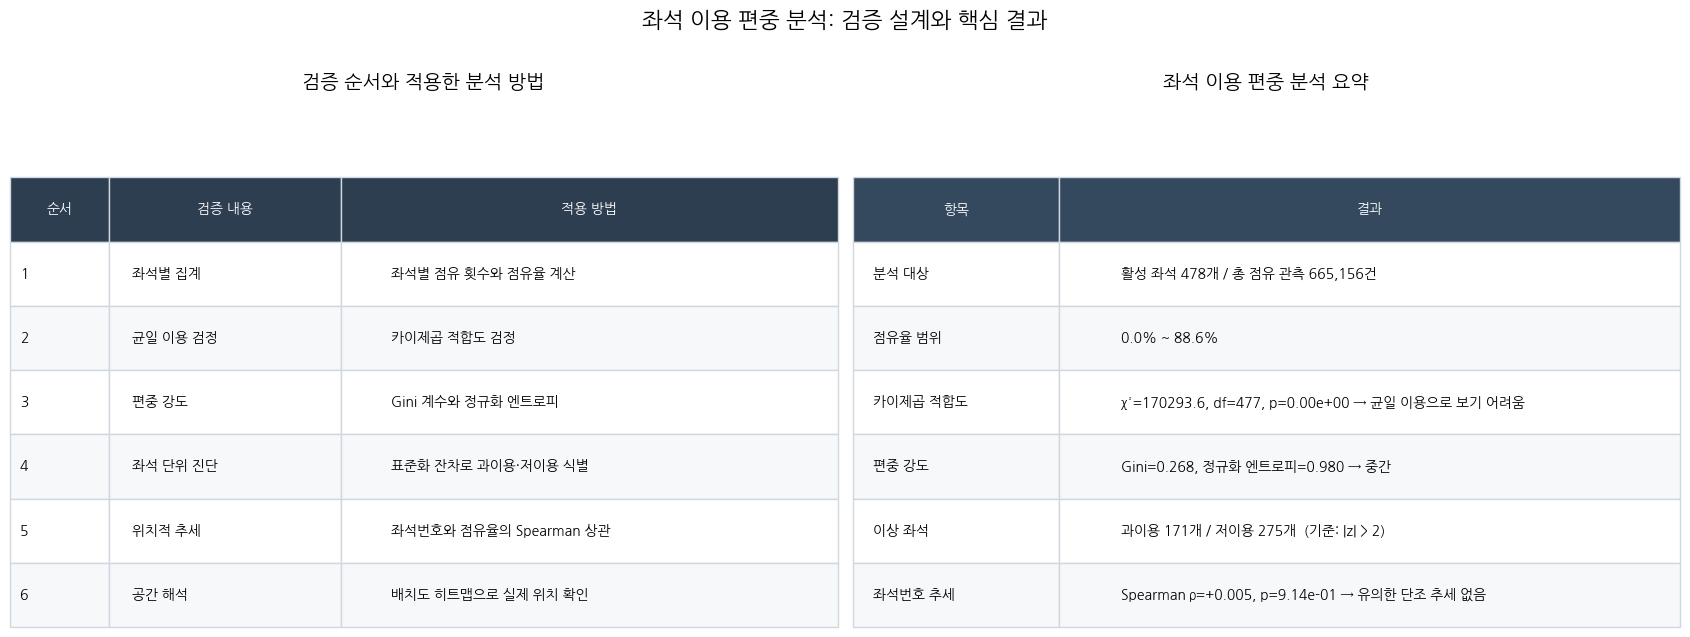

In [ ]:
# 좌석 이용 편중 분석: 집계, 검정, 편중 지표 계산
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 좌석별 점유 횟수와 점유율 집계
seat_occ = (
    df_seats
    .groupby('code_int')['isOccupied']
    .agg(점유횟수='sum', 총스냅샷='count')
    .reset_index()
    .rename(columns={'code_int': 'seat_num'})
)
seat_occ['점유율'] = seat_occ['점유횟수'] / seat_occ['총스냅샷']
seat_occ = (
    seat_occ.dropna(subset=['seat_num'])
            .sort_values('seat_num')
            .reset_index(drop=True)
)

# 카이제곱 적합도 검정: 모든 좌석이 동일하게 이용된다는 기준과 실제 점유 횟수 비교
observed = seat_occ['점유횟수'].to_numpy(dtype=float)
n_seats = len(observed)
total = observed.sum()
expected = np.full(n_seats, total / n_seats)

chi2_stat, chi2_p = stats.chisquare(f_obs=observed, f_exp=expected)
dof = n_seats - 1

# 편중 강도 지표
def gini(arr):
    arr = np.sort(np.asarray(arr, dtype=float))
    n = len(arr)
    if arr.sum() == 0:
        return 0.0
    return (2 * np.sum(np.arange(1, n + 1) * arr) - (n + 1) * arr.sum()) / (n * arr.sum())

def normalized_entropy(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.sum() == 0:
        return 0.0
    p = arr / arr.sum()
    p = p[p > 0]
    return float(-np.sum(p * np.log(p)) / np.log(len(arr)))

g = gini(observed)
H_norm = normalized_entropy(observed)

if g < 0.2:
    편중강도 = '약함'
elif g < 0.4:
    편중강도 = '중간'
else:
    편중강도 = '강함'

# 표준화 잔차: 기대 대비 과이용·저이용 좌석 식별
seat_occ['expected'] = expected
seat_occ['std_resid'] = (observed - expected) / np.sqrt(expected)
resid_cutoff = 2

over_used = seat_occ.nlargest(5, 'std_resid')[['seat_num', '점유횟수', '점유율', 'std_resid']]
under_used = seat_occ.nsmallest(5, 'std_resid')[['seat_num', '점유횟수', '점유율', 'std_resid']]
n_over_sig = int((seat_occ['std_resid'] > resid_cutoff).sum())
n_under_sig = int((seat_occ['std_resid'] < -resid_cutoff).sum())

# 좌석번호와 점유율의 단조 추세
rho, rho_p = stats.spearmanr(seat_occ['seat_num'], seat_occ['점유율'])

uniform_result = '균일 이용으로 보기 어려움' if chi2_p < 0.05 else '균일 이용과 구분 어려움'
trend_direction = '증가' if rho > 0 else '감소'
trend_result = f'{trend_direction} 추세 유의' if rho_p < 0.05 else '유의한 단조 추세 없음'

analysis_summary = pd.DataFrame([
    ['분석 대상', f'활성 좌석 {n_seats:,}개 / 총 점유 관측 {int(total):,}건'],
    ['점유율 범위', f'{seat_occ["점유율"].min() * 100:.1f}% ~ {seat_occ["점유율"].max() * 100:.1f}%'],
    ['카이제곱 적합도', f'χ²={chi2_stat:.1f}, df={dof}, p={chi2_p:.2e} → {uniform_result}'],
    ['편중 강도', f'Gini={g:.3f}, 정규화 엔트로피={H_norm:.3f} → {편중강도}'],
    ['이상 좌석', f'과이용 {n_over_sig}개 / 저이용 {n_under_sig}개  (기준: |z| > {resid_cutoff})'],
    ['좌석번호 추세', f'Spearman ρ={rho:+.3f}, p={rho_p:.2e} → {trend_result}'],
], columns=['항목', '결과'])

method_flow = pd.DataFrame([
    ['1', '좌석별 집계', '좌석별 점유 횟수와 점유율 계산'],
    ['2', '균일 이용 검정', '카이제곱 적합도 검정'],
    ['3', '편중 강도', 'Gini 계수와 정규화 엔트로피'],
    ['4', '좌석 단위 진단', '표준화 잔차로 과이용·저이용 식별'],
    ['5', '위치적 추세', '좌석번호와 점유율의 Spearman 상관'],
    ['6', '공간 해석', '배치도 히트맵으로 실제 위치 확인'],
], columns=['순서', '검증 내용', '적용 방법'])

fig, axes = plt.subplots(1, 2, figsize=(17, 6.2))
for ax in axes:
    ax.axis('off')

method_table = axes[0].table(
    cellText=method_flow.values,
    colLabels=method_flow.columns,
    cellLoc='left',
    colLoc='center',
    colWidths=[0.12, 0.28, 0.60],
    bbox=[0, 0, 1, 0.86]
)
method_table.auto_set_font_size(False)
method_table.set_fontsize(10)
for (row, col), cell in method_table.get_celld().items():
    cell.set_edgecolor('#d0d7de')
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', weight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f6f8fa')

axes[0].set_title('검증 순서와 적용한 분석 방법', fontsize=14, fontweight='bold', pad=12)

summary_table = axes[1].table(
    cellText=analysis_summary.values,
    colLabels=analysis_summary.columns,
    cellLoc='left',
    colLoc='center',
    colWidths=[0.25, 0.75],
    bbox=[0, 0, 1, 0.86]
)
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(10)
for (row, col), cell in summary_table.get_celld().items():
    cell.set_edgecolor('#d0d7de')
    if row == 0:
        cell.set_facecolor('#34495e')
        cell.set_text_props(color='white', weight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f6f8fa')

axes[1].set_title('좌석 이용 편중 분석 요약', fontsize=14, fontweight='bold', pad=12)

plt.suptitle('좌석 이용 편중 분석: 검증 설계와 핵심 결과', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**좌석 별 이용 분포, 편중 강도, 위치 추세 시각화**

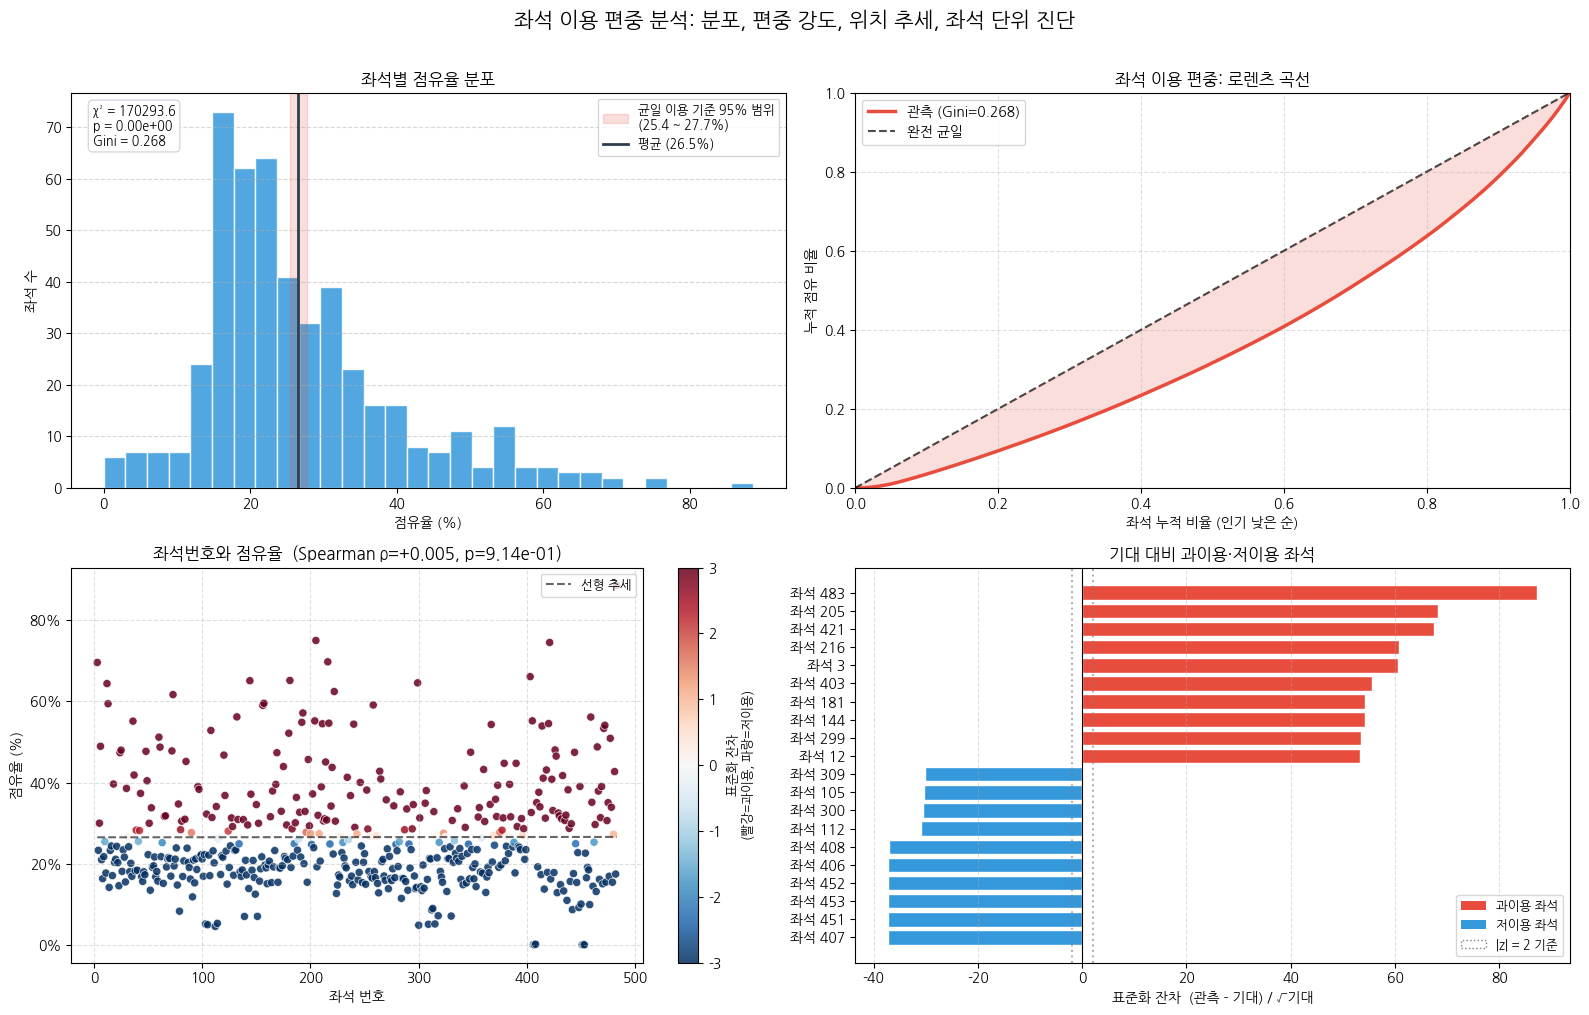

In [ ]:
# 좌석 이용 편중 진단 시각화
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) 좌석별 점유율 분포와 균일 이용 기준의 95% 범위
ax = axes[0, 0]
mean_rate = seat_occ['점유율'].mean()
n_snap = seat_occ['총스냅샷'].median()
se = np.sqrt(mean_rate * (1 - mean_rate) / n_snap)
lo, hi = (mean_rate - 1.96 * se) * 100, (mean_rate + 1.96 * se) * 100

ax.hist(
    seat_occ['점유율'] * 100,
    bins=30,
    color='#3498db',
    edgecolor='white',
    alpha=0.85
)
ax.axvspan(lo, hi, color='#e74c3c', alpha=0.18,
           label=f'균일 이용 기준 95% 범위\n({lo:.1f} ~ {hi:.1f}%)')
ax.axvline(mean_rate * 100, color='#2c3e50', linewidth=2,
           label=f'평균 ({mean_rate * 100:.1f}%)')
ax.set_title('좌석별 점유율 분포', fontsize=12, fontweight='bold')
ax.set_xlabel('점유율 (%)')
ax.set_ylabel('좌석 수')
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.text(
    0.03, 0.97,
    f'χ² = {chi2_stat:.1f}\np = {chi2_p:.2e}\nGini = {g:.3f}',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d7de', alpha=0.92)
)

# 2) 로렌츠 곡선
ax2 = axes[0, 1]
sorted_occ = np.sort(observed)
cum_share = np.concatenate([[0], np.cumsum(sorted_occ) / sorted_occ.sum()])
xs = np.linspace(0, 1, n_seats + 1)
ax2.plot(xs, cum_share, color='#e74c3c', linewidth=2.5, label=f'관측 (Gini={g:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.7, label='완전 균일')
ax2.fill_between(xs, cum_share, xs, color='#e74c3c', alpha=0.18)
ax2.set_title('좌석 이용 편중: 로렌츠 곡선', fontsize=12, fontweight='bold')
ax2.set_xlabel('좌석 누적 비율 (인기 낮은 순)')
ax2.set_ylabel('누적 점유 비율')
ax2.legend(loc='upper left', fontsize=10)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.grid(linestyle='--', alpha=0.4)

# 3) 좌석번호와 점유율
ax3 = axes[1, 0]
sc = ax3.scatter(
    seat_occ['seat_num'],
    seat_occ['점유율'] * 100,
    c=seat_occ['std_resid'],
    cmap='RdBu_r',
    vmin=-3,
    vmax=3,
    s=35,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.5
)
z3 = np.polyfit(seat_occ['seat_num'], seat_occ['점유율'] * 100, 1)
xr = np.linspace(seat_occ['seat_num'].min(), seat_occ['seat_num'].max(), 300)
ax3.plot(xr, np.poly1d(z3)(xr), 'k--', linewidth=1.5, alpha=0.6, label='선형 추세')
cbar = plt.colorbar(sc, ax=ax3)
cbar.set_label('표준화 잔차\n(빨강=과이용, 파랑=저이용)', fontsize=9)
ax3.set_title(f'좌석번호와 점유율  (Spearman ρ={rho:+.3f}, p={rho_p:.2e})',
              fontsize=12, fontweight='bold')
ax3.set_xlabel('좌석 번호')
ax3.set_ylabel('점유율 (%)')
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
ax3.legend(fontsize=9, loc='upper right')
ax3.grid(linestyle='--', alpha=0.4)

# 4) 표준화 잔차 상·하위 좌석
ax4 = axes[1, 1]
top10 = seat_occ.nlargest(10, 'std_resid').copy()
bot10 = seat_occ.nsmallest(10, 'std_resid').copy()
combo = pd.concat([bot10, top10]).sort_values('std_resid')
colors_bar = np.where(combo['std_resid'] >= 0, '#e74c3c', '#3498db')

ax4.barh(
    [f'좌석 {int(s)}' for s in combo['seat_num']],
    combo['std_resid'],
    color=colors_bar,
    edgecolor='white'
)
ax4.axvline(0, color='black', linewidth=0.8)
ax4.axvline(2, color='gray', linestyle=':', alpha=0.6)
ax4.axvline(-2, color='gray', linestyle=':', alpha=0.6)
ax4.set_title('기대 대비 과이용·저이용 좌석', fontsize=12, fontweight='bold')
ax4.set_xlabel('표준화 잔차  (관측 - 기대) / √기대')
ax4.legend(
    handles=[
        Patch(facecolor='#e74c3c', label='과이용 좌석'),
        Patch(facecolor='#3498db', label='저이용 좌석'),
        Patch(facecolor='none', edgecolor='gray', linestyle=':', label='|z| = 2 기준'),
    ],
    loc='lower right',
    fontsize=9
)
ax4.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('좌석 이용 편중 분석: 분포, 편중 강도, 위치 추세, 좌석 단위 진단',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**도서관 좌석 점유율 히트맵**

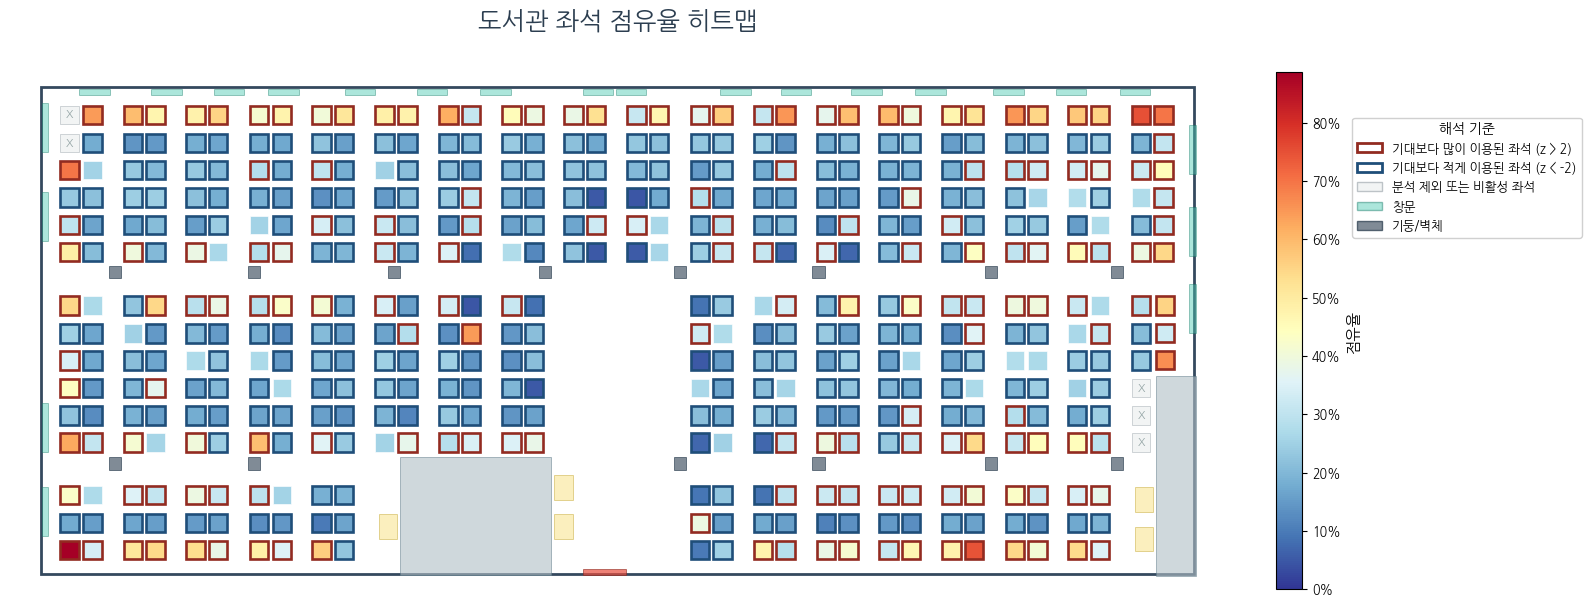

In [ ]:
# 도서관 좌석 점유율 히트맵: 실제 배치도 위에 편중 결과 표시
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

layout_elements = pd.DataFrame(layout_data.get('elements', [])).copy()
layout_elements['id_int'] = pd.to_numeric(layout_elements.get('id'), errors='coerce')

df_seat_analysis = pd.merge(
    seat_occ,
    layout_elements[layout_elements['category'] == 'seat'],
    left_on='seat_num',
    right_on='id_int',
    how='inner'
)

def add_rotated_rect(ax, x, y, w, h, r=0, **kwargs):
    rect = patches.Rectangle((x, y), w, h, **kwargs)
    cx, cy = x + w / 2, y + h / 2
    rect.set_transform(transforms.Affine2D().rotate_deg_around(cx, cy, r) + ax.transData)
    ax.add_patch(rect)
    return rect

def draw_occupancy_heatmap(df_analysis):
    room = layout_data.get('room', {})
    rw, rh = room.get('w', 1882), room.get('h', 795)
    elements = layout_data.get('elements', [])
    active_seat_ids = set(df_analysis['seat_num'].astype(int))

    vmax = df_analysis['점유율'].max()
    norm = plt.Normalize(vmin=0, vmax=vmax)
    cmap = plt.cm.RdYlBu_r

    fig, ax = plt.subplots(figsize=(16, 8))

    ax.add_patch(patches.Rectangle(
        (0, 0), rw, rh,
        linewidth=2,
        edgecolor='#34495e',
        facecolor='none',
        zorder=1
    ))

    element_style = {
        'door': ('#e74c3c', '#922b21', 0.70),
        'window': ('#48c9b0', '#117864', 0.45),
        'pillar': ('#566573', '#2c3e50', 0.75),
        'wall': ('#b0bec5', '#607d8b', 0.60),
        'motion': ('#f7dc6f', '#b7950b', 0.45),
    }

    for el in elements:
        cat = el.get('category')
        x, y = el.get('x', 0), el.get('y', 0)
        w, h = el.get('w', 20), el.get('h', 20)
        r = el.get('r', 0)
        cx, cy = x + w / 2, y + h / 2

        if cat != 'seat':
            facecolor, edgecolor, alpha = element_style.get(cat, ('#d5dbdb', '#95a5a6', 0.35))
            add_rotated_rect(
                ax, x, y, w, h, r,
                facecolor=facecolor,
                edgecolor=edgecolor,
                linewidth=0.6,
                alpha=alpha,
                zorder=2
            )
            continue

        sid = pd.to_numeric(el.get('id'), errors='coerce')
        if pd.isna(sid) or int(sid) not in active_seat_ids:
            add_rotated_rect(
                ax, x, y, w, h, r,
                facecolor='#f2f4f4',
                edgecolor='#bdc3c7',
                linewidth=0.5,
                zorder=1
            )
            ax.text(cx, cy, 'X', color='#95a5a6',
                    ha='center', va='center',
                    fontsize=8, fontweight='bold', zorder=2)

    for _, row in df_analysis.iterrows():
        x, y, w, h = row['x'], row['y'], row['w'], row['h']
        r = row.get('r', 0)
        z = row['std_resid']

        edgecolor = 'white'
        linewidth = 0.45
        zorder = 3
        if z > 2:
            edgecolor = '#922b21'
            linewidth = 1.9
            zorder = 4
        elif z < -2:
            edgecolor = '#1f4e79'
            linewidth = 1.9
            zorder = 4

        add_rotated_rect(
            ax, x, y, w, h, r,
            facecolor=cmap(norm(row['점유율'])),
            edgecolor=edgecolor,
            linewidth=linewidth,
            zorder=zorder
        )

    ax.set_xlim(-50, rw + 50)
    ax.set_ylim(-50, rh + 50)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')

    ax.set_title('도서관 좌석 점유율 히트맵',
                 fontsize=18, pad=20, fontweight='bold', color='#2c3e50')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.04)
    cbar.set_label('점유율', fontsize=11)
    cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    cbar.ax.tick_params(labelsize=9)

    n_over = int((df_analysis['std_resid'] > 2).sum())
    n_under = int((df_analysis['std_resid'] < -2).sum())

    legend_elements = [
        Patch(facecolor='none', edgecolor='#922b21', linewidth=2,
              label='기대보다 많이 이용된 좌석 (z > 2)'),
        Patch(facecolor='none', edgecolor='#1f4e79', linewidth=2,
              label='기대보다 적게 이용된 좌석 (z < -2)'),
        Patch(facecolor='#f2f4f4', edgecolor='#bdc3c7',
              label='분석 제외 또는 비활성 좌석'),
        Patch(facecolor='#48c9b0', edgecolor='#117864', alpha=0.45,
              label='창문'),
        Patch(facecolor='#566573', edgecolor='#2c3e50', alpha=0.75,
              label='기둥/벽체'),
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper left',
        bbox_to_anchor=(1.1, 0.9),
        fontsize=9,
        framealpha=0.92,
        title='해석 기준',
        title_fontsize=10
    )

    plt.tight_layout()
    plt.show()

draw_occupancy_heatmap(df_seat_analysis)

**A. 좌석 이용 편중 분석 결과**

- 활성 좌석 478개 / 총 점유 관측 665,156건
  - 전체 열람실 이용 데이터 기준으로 좌석별 사용 패턴 분석 수행

- **좌석별 점유율 범위**: 0.0% ~ **88.6%**
  - 거의 사용되지 않는 좌석과 항상 점유되는 좌석이 동시에 존재하며 좌석 간 이용 차이가 크게 나타남

- **카이제곱 적합도 검정**: χ²=170,293.6, p≈0
  - 균일 이용 귀무가설 강하게 기각
  - **좌석 간 이용 편중 존재**
  - 좌석 이용 편중은 우연이 아닌 통계적으로 유의한 구조적 현상으로 해석 가능

- **편중 강도**
  - Gini = 0.268
  - 정규화 엔트로피 = 0.980
  - **중간 수준 편중 구조**
  - 일부 좌석에 이용이 집중되지만 극소수 좌석만 독점되는 수준은 아님

- **표준화 잔차**(|z|>2)
  - 과이용 좌석: 171개
  - 저이용 좌석: 275개
  - **기대 대비 이용 편차 뚜렷**
  - 평균 대비 유의하게 많이 사용되거나 기피되는 좌석이 다수 존재함

- **Spearman 상관분석**
  - ρ = +0.005
  - p = 0.912
  - **좌석번호와 점유율 간 단조 추세 없음**
  - 단순한 앞번호·뒷번호 선호 패턴은 확인되지 않음

- **히트맵 결과**
  - **벽면·가장자리**·특정 구역 → **과이용** 집중
  - **중앙부·통로 인접** 좌석 → **저이용** 경향
  - 공간적 군집 패턴 확인
  - 실제 좌석 위치에 따라 선호·기피 현상이 공간적으로 분포함을 확인

- **종합 해석**
  - 단순 좌석번호 효과 X
  - **위치·환경 요인 영향 가능성 높음**
  - 출입문 거리, 독립성, 공간 배치 효과 추정
  - 좌석 이용 편중은 번호 순서보다 실제 공간적·환경적 특성의 영향을 더 크게 받는 것으로 해석됨

---
### B. 좌석과 출입문·창문·기둥의 위치관계 분석

**분석 질문**: 선호 좌석과 비선호 좌석의 차이가 단순한 좌석번호 편중을 넘어, 출입문·창문·기둥과의 거리 및 열람실 가장자리 조건과도 연결되는가?


**분석 및 검증 과정**

1. 좌석 중심점 기준 출입문·창문·기둥까지 최근접 거리 계산

2. 열람실 외곽·기둥·void space 인접 정도를 **가장자리 점수**(0~1)로 수치화

3. 좌석별 위치 특성 데이터와 점유율 데이터 결합

4. Spearman 상관분석으로 위치 요인과 점유율 간 관계 검증


**좌석과 주요 공간 요소의 거리 및 가장자리 점수 계산**

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from IPython.display import display

# 1. 분석에 필요한 메타데이터 설정 (이후 시각화와 변수명 통일)
spatial_metric_info = [
    {'label': '출입문 거리', 'col': 'door_dist', 'kind': 'distance', 'color': '#e74c3c', 'xlabel': '가장 가까운 출입문까지 거리'},
    {'label': '창문 거리', 'col': 'window_dist', 'kind': 'distance', 'color': '#16a085', 'xlabel': '가장 가까운 창문까지 거리'},
    {'label': '기둥 거리', 'col': 'pillar_dist', 'kind': 'distance', 'color': '#7f8c8d', 'xlabel': '가장 가까운 기둥까지 거리'},
    {'label': '가장자리 점수', 'col': 'edge_score', 'kind': 'score', 'color': '#8e44ad', 'xlabel': '가장자리 점수 (0=내부, 1=가장자리)'}
]

# 2. 배치도 데이터 기반 좌표 데이터프레임 생성
layout_elements = pd.DataFrame(layout_data.get('elements', [])).copy()
layout_elements['id_int'] = pd.to_numeric(layout_elements.get('id'), errors='coerce')
for col in ['x', 'y', 'w', 'h']:
    layout_elements[col] = pd.to_numeric(layout_elements[col], errors='coerce')

layout_elements['center_x'] = layout_elements['x'] + layout_elements['w'] / 2
layout_elements['center_y'] = layout_elements['y'] + layout_elements['h'] / 2

# 3. 실측 점유율 데이터(seat_occ)와 위치 데이터 결합
seat_layout = layout_elements[layout_elements['category'] == 'seat'].dropna(subset=['id_int', 'center_x', 'center_y']).copy()
# seat_occ 변수(A절에서 생성됨)를 활용
seat_spatial = seat_layout.merge(seat_occ[['seat_num', '점유율', 'std_resid']], left_on='id_int', right_on='seat_num', how='inner')

# 4. 각 요소별 최단 거리 계산
for feature in ['door', 'window', 'pillar']:
    feat_df = layout_elements[layout_elements['category'] == feature].dropna(subset=['center_x', 'center_y'])
    dist_col = f"{feature}_dist"
    if not feat_df.empty:
        f_xy = feat_df[['center_x', 'center_y']].values
        s_xy = seat_spatial[['center_x', 'center_y']].values
        dists = np.sqrt(((s_xy[:, None, :] - f_xy[None, :, :]) ** 2).sum(axis=2))
        seat_spatial[dist_col] = dists.min(axis=1)
    else:
        seat_spatial[dist_col] = np.nan

# 5. 가장자리 점수(Edge Score) 계산
room = layout_data.get('room', {})
rw, rh = room.get('w', 1882), room.get('h', 795)
room_edge = np.minimum.reduce([
    seat_spatial['center_x'], seat_spatial['center_y'],
    rw - seat_spatial['center_x'], rh - seat_spatial['center_y']
])

edge_elements = layout_elements[
    (layout_elements['category'] == 'pillar') |
    (layout_elements['id'].fillna('').str.contains('void', case=False))
].copy()

def get_rect_dist(px, py, rects):
    if rects.empty: return np.inf
    dists = []
    for _, r in rects.iterrows():
        dx = max(r['x'] - px, 0, px - (r['x'] + r['w']))
        dy = max(r['y'] - py, 0, py - (r['y'] + r['h']))
        dists.append(np.sqrt(dx**2 + dy**2))
    return min(dists)

seat_spatial['obj_edge_dist'] = seat_spatial.apply(lambda r: get_rect_dist(r['center_x'], r['center_y'], edge_elements), axis=1)
seat_spatial['edge_dist'] = np.minimum(room_edge, seat_spatial['obj_edge_dist'])
e_min, e_max = seat_spatial['edge_dist'].min(), seat_spatial['edge_dist'].max()
seat_spatial['edge_score'] = 1 - (seat_spatial['edge_dist'] - e_min) / (e_max - e_min)

# 6. 통계 분석 및 spatial_summary 생성
summary_data = []
for m in spatial_metric_info:
    valid = seat_spatial[[m['col'], '점유율']].dropna()
    rho, p = stats.spearmanr(valid[m['col']], valid['점유율'])
    summary_data.append({
        '공간요소': m['label'],
        '변수': m['col'],
        '점유율 Spearman ρ': rho,
        'p-value': p,
        '유의성': '유의' if p < 0.05 else '유의하지 않음'
    })

spatial_summary = pd.DataFrame(summary_data)

print("공간 요소와 점유율 상관관계")
display(spatial_summary.round(4))

print("\n선호 상위 10개 좌석의 공간적 특징")
display(seat_spatial.nlargest(10, '점유율')[['seat_num', '점유율', 'edge_score', 'door_dist', 'window_dist']].round(3))

공간 요소와 점유율 상관관계


,공간요소,변수,점유율 Spearman ρ,p-value,유의성
0,출입문 거리,door_dist,0.2782,0.0000,유의
1,창문 거리,window_dist,-0.2169,0.0000,유의
2,기둥 거리,pillar_dist,0.0487,0.2906,유의하지 않음
3,가장자리 점수,edge_score,0.4546,0.0000,유의



선호 상위 10개 좌석의 공간적 특징


,seat_num,점유율,edge_score,door_dist,window_dist
471,483,0.886,0.892,872.743,73.783
202,205,0.750,0.860,1150.605,38.328
412,421,0.746,0.892,605.072,531.010
213,216,0.698,0.860,1179.019,59.816
0,3,0.696,0.845,1091.201,79.756
397,403,0.661,0.975,978.234,95.294
178,181,0.652,0.860,1002.704,38.328
141,144,0.651,0.860,802.578,40.719
296,299,0.646,0.236,445.432,396.025
4,12,0.644,0.860,1119.706,37.121


**좌석과 주요 공간 요소의 거리 및 가장자리 점수와 좌석 선호도 간의 유의성 검증**

,공간요소,점유율 Spearman ρ,p-value,유의성
0,출입문 거리,0.2782,0.0000,유의
1,창문 거리,-0.2169,0.0000,유의
2,기둥 거리,0.0487,0.2906,유의하지 않음
3,가장자리 점수,0.4546,0.0000,유의


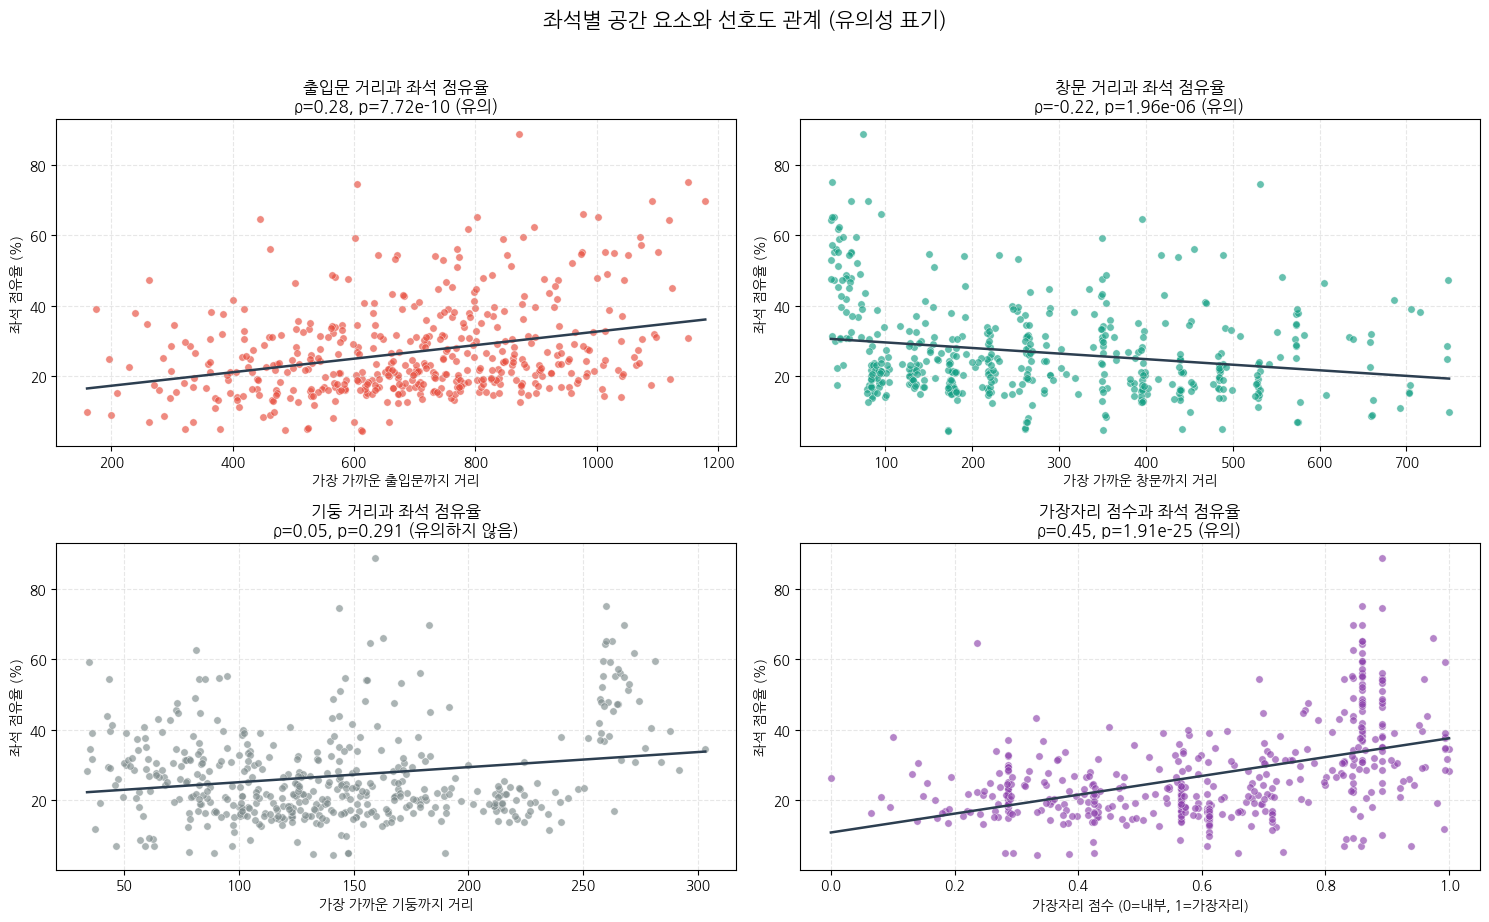

In [ ]:
# 공간요소별 유의성
SIGNIFICANCE_ALPHA = 0.05
import pandas as pd

spatial_summary['유의성'] = spatial_summary['p-value'].apply(lambda p: '유의' if pd.notna(p) and p < SIGNIFICANCE_ALPHA else '유의하지 않음')
display(spatial_summary[['공간요소','점유율 Spearman ρ','p-value','유의성']].round(4))

import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.ravel()
for ax, metric in zip(axes, spatial_metric_info):
    col = metric['col']
    valid = seat_spatial[[col, '점유율']].dropna()
    ax.scatter(
        valid[col],
        valid['점유율'] * 100,
        s=28,
        alpha=0.65,
        color=metric['color'],
        edgecolor='white',
        linewidth=0.4
    )

    if len(valid) >= 3 and valid[col].nunique() > 1:
        rho, p_value = stats.spearmanr(valid[col], valid['점유율'])
        z = np.polyfit(valid[col], valid['점유율'] * 100, 1)
        x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
        ax.plot(x_line, z[0] * x_line + z[1], color='#2c3e50', linewidth=1.8)
        sig = '유의' if p_value < SIGNIFICANCE_ALPHA else '유의하지 않음'
        stat_text = f'ρ={rho:.2f}, p={p_value:.3g} ({sig})'
    else:
        stat_text = '비교 데이터 부족'

    ax.set_title(f"{metric['label']}과 좌석 점유율\n{stat_text}", fontsize=12, fontweight='bold')
    ax.set_xlabel(metric['xlabel'])
    ax.set_ylabel('좌석 점유율 (%)')
    ax.grid(alpha=0.3, linestyle='--')

for ax in axes[len(spatial_metric_info):]:
    ax.axis('off')

plt.suptitle('좌석별 공간 요소와 선호도 관계 (유의성 표기)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**유의한 공간 요소와 선호도 간 비교 시각화**

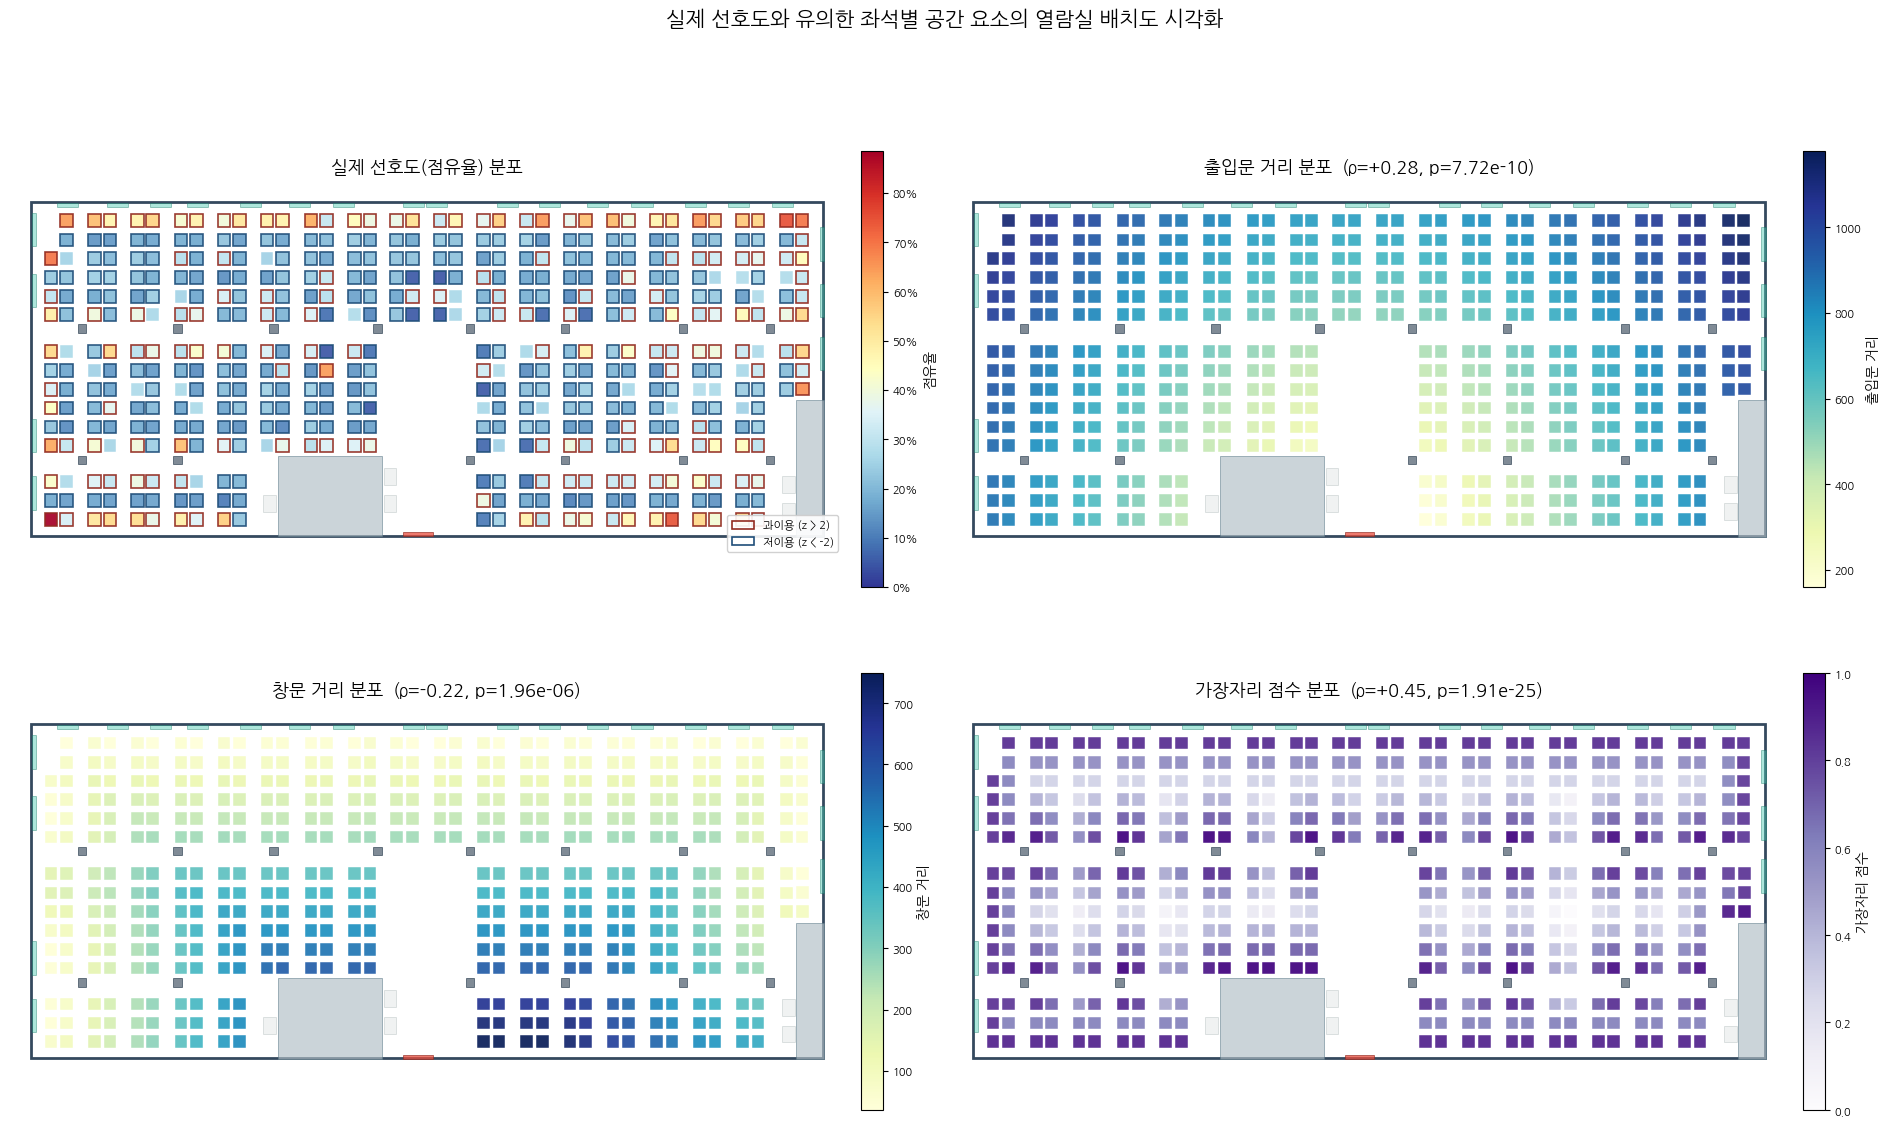

In [ ]:
# 실제 선호도와 유의한 공간 요소를 배치도 위에 시각화
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize
from math import ceil
import pandas as pd

SIGNIFICANCE_ALPHA = 0.05

significant_metric_info = []
for metric in spatial_metric_info:
    row = spatial_summary.loc[
        (spatial_summary['변수'] == metric['col'])
        & (spatial_summary['p-value'] < SIGNIFICANCE_ALPHA)
    ]
    if row.empty:
        continue
    metric_with_stats = metric.copy()
    metric_with_stats['rho'] = row['점유율 Spearman ρ'].iloc[0]
    metric_with_stats['p_value'] = row['p-value'].iloc[0]
    # 각 메트릭 종류에 맞는 기본 cmap 추가
    if metric['kind'] == 'distance':
        metric_with_stats['cmap'] = 'YlGnBu'
    elif metric['kind'] == 'score':
        metric_with_stats['cmap'] = 'Purples'
    metric_with_stats['colorbar_label'] = metric['label']
    significant_metric_info.append(metric_with_stats)

preference_metric_info = {
    'label': '실제 선호도(점유율)',
    'col': '점유율',
    'kind': 'preference',
    'cmap': 'RdYlBu_r',
    'colorbar_label': '점유율',
}

def add_rotated_rect(ax, x, y, w, h, r=0, **kwargs):
    rect = patches.Rectangle((x, y), w, h, **kwargs)
    cx, cy = x + w / 2, y + h / 2
    rect.set_transform(transforms.Affine2D().rotate_deg_around(cx, cy, r) + ax.transData)
    ax.add_patch(rect)
    return rect

def get_value_norm(values, metric):
    values = values.dropna()
    if metric['kind'] == 'score':
        return Normalize(vmin=0, vmax=1)
    if metric['kind'] == 'preference':
        vmax = values.max() if len(values) else 1
        return Normalize(vmin=0, vmax=max(vmax, 0.01))

    vmin = values.min() if len(values) else 0
    vmax = values.max() if len(values) else 1
    if pd.isna(vmin) or pd.isna(vmax) or vmin == vmax:
        return Normalize(vmin=0, vmax=1)
    return Normalize(vmin=vmin, vmax=vmax)

def draw_background_elements(ax, elements):
    for el in elements:
        cat = el.get('category')
        if cat == 'seat':
            continue

        x, y = el.get('x', 0), el.get('y', 0)
        w, h = el.get('w', 20), el.get('h', 20)
        r = el.get('r', 0)

        if cat == 'door':
            facecolor, edgecolor, alpha = '#e74c3c', '#922b21', 0.75
        elif cat == 'window':
            facecolor, edgecolor, alpha = '#48c9b0', '#117864', 0.45
        elif cat == 'pillar':
            facecolor, edgecolor, alpha = '#566573', '#2c3e50', 0.75
        elif cat == 'wall':
            facecolor, edgecolor, alpha = '#b0bec5', '#607d8b', 0.65
        else:
            facecolor, edgecolor, alpha = '#d5dbdb', '#95a5a6', 0.35

        add_rotated_rect(
            ax, x, y, w, h, r,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=0.6,
            alpha=alpha,
            zorder=2
        )

def draw_seat_value_map(ax, metric, norm):
    cmap = plt.get_cmap(metric['cmap'])
    col = metric['col']

    for _, row in seat_spatial.dropna(subset=[col]).iterrows():
        x, y = row['x'], row['y']
        w, h = row['w'], row['h']
        r = row.get('r', 0)
        edgecolor = 'white'
        linewidth = 0.35

        if metric['kind'] == 'preference':
            if row.get('std_resid', 0) > 2:
                edgecolor = '#922b21'
                linewidth = 1.2
            elif row.get('std_resid', 0) < -2:
                edgecolor = '#1f4e79'
                linewidth = 1.2

        add_rotated_rect(
            ax, x, y, w, h, r,
            facecolor=cmap(norm(row[col])),
            edgecolor=edgecolor,
            linewidth=linewidth,
            alpha=0.92,
            zorder=3
        )

def draw_preference_and_significant_metric_maps(metrics):
    if not metrics:
        print(f'p < {SIGNIFICANCE_ALPHA} 기준으로 유의한 공간 요소는 없지만, 실제 선호도 배치도는 표시합니다.')

    room = layout_data.get('room', {})
    rw, rh = room.get('w', 1882), room.get('h', 795)
    elements = layout_data.get('elements', [])
    maps_to_draw = [preference_metric_info] + metrics

    n = len(maps_to_draw)
    ncols = min(2, n)
    nrows = ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(9.5 * ncols, 5.8 * nrows), squeeze=False)
    axes = axes.ravel()

    for ax, metric in zip(axes, maps_to_draw):
        col = metric['col']
        norm = get_value_norm(seat_spatial[col], metric)
        cmap = plt.get_cmap(metric['cmap'])

        ax.add_patch(patches.Rectangle(
            (0, 0), rw, rh,
            linewidth=2,
            edgecolor='#34495e',
            facecolor='none',
            zorder=1
        ))

        draw_background_elements(ax, elements)
        draw_seat_value_map(ax, metric, norm)

        ax.set_xlim(-50, rw + 50)
        ax.set_ylim(-50, rh + 50)
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.axis('off')

        if metric['kind'] == 'preference':
            title = f"{metric['label']} 분포"
        else:
            title = f"{metric['label']} 분포  (ρ={metric['rho']:+.2f}, p={metric['p_value']:.3g})"
        ax.set_title(title, fontsize=13, fontweight='bold')

        if metric['kind'] == 'preference':
            legend_elements = [
                patches.Patch(facecolor='none', edgecolor='#922b21', linewidth=1.2,
                              label='과이용 (z > 2)'),
                patches.Patch(facecolor='none', edgecolor='#1f4e79', linewidth=1.2,
                              label='저이용 (z < -2)'),
            ]
            ax.legend(handles=legend_elements, loc='lower right',
                      fontsize=8, framealpha=0.9)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
        cbar.set_label(metric['colorbar_label'], fontsize=10)
        if metric['kind'] == 'preference':
            cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        cbar.ax.tick_params(labelsize=8)

    for ax in axes[n:]:
        ax.axis('off')

    plt.suptitle('실제 선호도와 유의한 좌석별 공간 요소의 열람실 배치도 시각화',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

draw_preference_and_significant_metric_maps(significant_metric_info)

**B. 좌석과 출입문·창문·기둥의 위치관계 분석 결과**

- **출입문 거리**
  - **ρ = 0.28, p < .001**
  - 유의한 양의 상관
  - **출입문에서 멀수록 점유율 증가**
  - 이동·소음·시선 노출 회피 경향 추정

- **창문 거리**
  - **ρ = -0.22, p < .001**
  - 유의한 음의 상관
  - **창문에 가까울수록 점유율 증가**
  - 채광·개방감·벽면 안정감 선호 가능성

- **기둥 거리**
  - **ρ = 0.05, p = 0.291**
  - 통계적으로 유의하지 않음
  - **기둥 위치 자체는 좌석 선호도 설명력 낮음**

- **가장자리 점수**
  - **ρ = 0.45, p < .001**
  - **가장 강한 양의 상관**
  - **벽면·모서리·외곽 좌석 선호 경향 뚜렷**
  - 독립성·심리적 안정감 영향 가능성

- **히트맵 시각화**
  - 상단 벽면·외곽 구역 → 고점유 집중
  - 중앙부·통로 인접 좌석 → 저점유 경향
  - 공간적 군집 패턴 확인

- **종합 해석**
  - **출입문 거리·가장자리 점수가 좌석 점유율(선호도)의 핵심 공간 요인**으로 나타남
  - 콘센트 조건이 동일한 1열람실 환경에서 좌석 스펙보다 **위치적 안정감** 영향 가능성 높음

  - Prospect-Refuge Theory (Appleton, 1975):“등 뒤는 막히고(refuge), 앞은 트인(prospect) 공간”선호 경향 확인
  
  - 설문(Q11)에서는 출입문 거리 중요도를 낮게 응답(2.74/5)했지만, 실제 행동에서는 출입문 먼 좌석 선호(ρ=0.28) 확인
  - **stated preference ≠ revealed preference**
  - **이용자가 인식하지 못하는 무의식적 공간 선호 가능성** 시사


---
### C. 시간대별 점유율 차이 분석

**분석 질문**: 오전 5-12시, 오후 12-19시, 저녁 19-익일 1시에 따라 도서관 좌석 점유율이 달라지는가? (*새벽시간 1-5시 데이터 수집 X)


**분석 및 검증과정**
1. 스냅샷 단위 점유율 집계
2. 설문과 동일한 4개 시간대별 기술통계 비교
3. **Kruskal-Wallis 검정**으로 시간대 간 차이 확인
4. **Mann-Whitney U + Bonferroni 보정**으로 어느 시간대끼리 다른지 확인


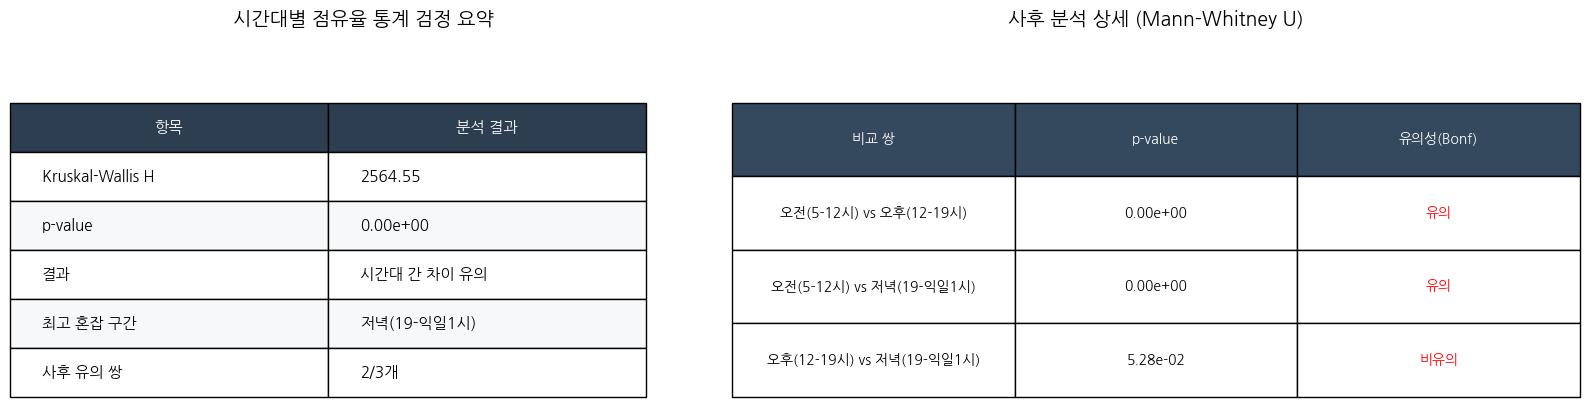

In [ ]:
# ── 시간대별 점유율 차이 분석 (통계 검정 및 시각화) ──────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from itertools import combinations

# 1. 데이터 집계: 스냅샷(collected_at)별 전체 점유율
snap_occ = (
    df_seats
    .groupby('collected_at')['isOccupied']
    .mean()
    .rename('occ_rate')
    .reset_index()
)
snap_occ['hour']   = snap_occ['collected_at'].dt.hour
snap_occ['period'] = snap_occ['hour'].apply(label_period)

# 2. 시간대별 기술통계
period_stats = (
    snap_occ.groupby('period')['occ_rate']
    .agg(스냅샷수='count', 평균점유율='mean', 표준편차='std', 중앙값='median')
    .reindex(PERIOD_ORDER)
    .fillna(0)
)

# 3. Kruskal-Wallis 검정 (비모수 분산분석)
groups_h1 = [snap_occ[snap_occ['period'] == p]['occ_rate'].values
             for p in PERIOD_ORDER if len(snap_occ[snap_occ['period'] == p]) > 0]
kw_stat, kw_p = stats.kruskal(*groups_h1)

# 4. 사후 Mann-Whitney U (Bonferroni 보정)
pairs = list(combinations(PERIOD_ORDER, 2))
alpha_b = 0.05 / len(pairs)
posthoc_results = []
for p1, p2 in pairs:
    g1 = snap_occ[snap_occ['period'] == p1]['occ_rate'].values
    g2 = snap_occ[snap_occ['period'] == p2]['occ_rate'].values
    if len(g1) == 0 or len(g2) == 0: continue
    u_stat, u_p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    posthoc_results.append([f"{p1} vs {p2}", f"{u_p:.2e}", '유의' if u_p < alpha_b else '비유의'])

# 5. 결과 시각화
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.2])

# [왼쪽 위] 통계 요약표
ax_table = fig.add_subplot(gs[0, 0])
ax_table.axis('off')
summary_data = [
    ['Kruskal-Wallis H', f"{kw_stat:.2f}"],
    ['p-value', f"{kw_p:.2e}"],
    ['결과', '시간대 간 차이 유의' if kw_p < 0.05 else '유의하지 않음'],
    ['최고 혼잡 구간', f"{period_stats['평균점유율'].idxmax()}"],
    ['사후 유의 쌍', f"{sum(1 for r in posthoc_results if r[2]=='유의')}/{len(posthoc_results)}개"]
]
tbl1 = ax_table.table(cellText=summary_data, colLabels=['항목', '분석 결과'], loc='center', cellLoc='left', bbox=[0, 0, 0.9, 0.8])
tbl1.auto_set_font_size(False); tbl1.set_fontsize(11)
for (r, c), cell in tbl1.get_celld().items():
    if r == 0: cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', weight='bold')
    elif r % 2 == 0: cell.set_facecolor('#f6f8fa')
ax_table.set_title("시간대별 점유율 통계 검정 요약", fontsize=14, fontweight='bold', pad=1)

# [오른쪽 위] 사후 검정 상세 표
ax_post = fig.add_subplot(gs[0, 1])
ax_post.axis('off')
tbl2 = ax_post.table(cellText=posthoc_results, colLabels=['비교 쌍', 'p-value', '유의성(Bonf)'], loc='center', cellLoc='center', bbox=[0, 0, 1, 0.8])
tbl2.auto_set_font_size(False); tbl2.set_fontsize(10)
for (r, c), cell in tbl2.get_celld().items():
    if r == 0: cell.set_facecolor('#34495e'); cell.set_text_props(color='white', weight='bold')
    if c == 2 and r > 0 and '유의' in cell.get_text().get_text() and '하지' not in cell.get_text().get_text():
        cell.set_text_props(color='red', weight='bold')
ax_post.set_title("사후 분석 상세 (Mann-Whitney U)", fontsize=14, fontweight='bold', pad=1)

plt.tight_layout()
plt.show()

**시간대별 이용 패턴 분석 시각화**

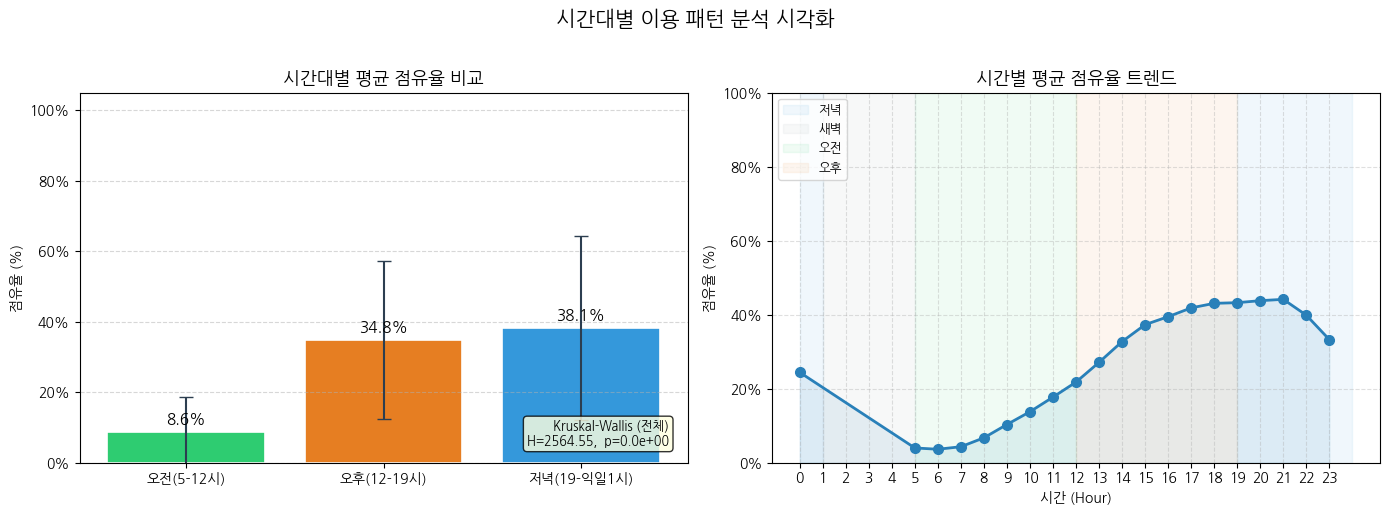


[시간대별 이용 패턴 분석 결과]
  · 최고 혼잡 시간대: 저녁(19-익일1시) (38.1%)
  · 최저 혼잡 시간대: 오전(5-12시) (8.6%)
  · 통계적 유의성(전체): 유의미한 차이 존재 (p < 0.05)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
BAR_COLORS_FULL = ['#95a5a6', '#2ecc71', '#e67e22', '#3498db']

PERIOD_MAP_KO = {
    '새벽(1-5시)': '새벽(1-5시)',
    '오전(5-12시)': '오전(5-12시)',
    '오후(12-19시)': '오후(12-19시)',
    '저녁(19-익일1시)': '저녁(19-익일1시)'
}

filtered_periods = [p for p in PERIOD_ORDER if p != '새벽(1-5시)']
ko_periods = [PERIOD_MAP_KO[p] for p in filtered_periods]
filtered_stats = period_stats.loc[filtered_periods]
BAR_COLORS = ['#2ecc71', '#e67e22', '#3498db']

ax = axes[0]
bars = ax.bar(ko_periods, filtered_stats['평균점유율'] * 100,
              color=BAR_COLORS, edgecolor='white', linewidth=1.2)
ax.errorbar(ko_periods, filtered_stats['평균점유율'] * 100,
            yerr=filtered_stats['표준편차'] * 100,
            fmt='none', color='#2c3e50', capsize=5, linewidth=1.5)
for bar, val in zip(bars, filtered_stats['평균점유율']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('시간대별 평균 점유율 비교', fontsize=13, fontweight='bold')
ax.set_ylabel('점유율 (%)')
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.text(0.97, 0.04, f'Kruskal-Wallis (전체)\nH={kw_stat:.2f},  p={kw_p:.1e}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax2 = axes[1]
hourly = snap_occ.groupby('hour')['occ_rate'].mean() * 100
ax2.plot(hourly.index, hourly.values, 'o-', color='#2980b9',
         linewidth=2, markersize=7, zorder=3)
ax2.fill_between(hourly.index, hourly.values, alpha=0.1, color='#2980b9')

zone_cfg = [
    (0, 1, '#3498db', '저녁'),
    (1, 5, '#95a5a6', '새벽'),
    (5, 12, '#2ecc71', '오전'),
    (12, 19, '#e67e22', '오후'),
    (19, 24, '#3498db', '저녁'),
]
seen_labels = set()
for s, e, c, lbl in zone_cfg:
    label = lbl if lbl not in seen_labels else '_nolegend_'
    ax2.axvspan(s, e, alpha=0.07, color=c, label=label)
    seen_labels.add(lbl)
ax2.set_title('시간별 평균 점유율 트렌드', fontsize=13, fontweight='bold')
ax2.set_xlabel('시간 (Hour)')
ax2.set_ylabel('점유율 (%)')
ax2.set_xticks(range(0, 24))
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(linestyle='--', alpha=0.4)

plt.suptitle('시간대별 이용 패턴 분석 시각화', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

peak = period_stats['평균점유율'].idxmax()
low = filtered_stats['평균점유율'].idxmin()
print('\n[시간대별 이용 패턴 분석 결과]')
print(f'  · 최고 혼잡 시간대: {peak} ({period_stats.loc[peak, "평균점유율"]*100:.1f}%)')
print(f'  · 최저 혼잡 시간대: {low} ({filtered_stats.loc[low, "평균점유율"]*100:.1f}%)')
print(f'  · 통계적 유의성(전체): {"유의미한 차이 존재 (p < 0.05)" if kw_p < 0.05 else "차이 없음"}')

**시간대별 상위 30개 선호 좌석 비교**

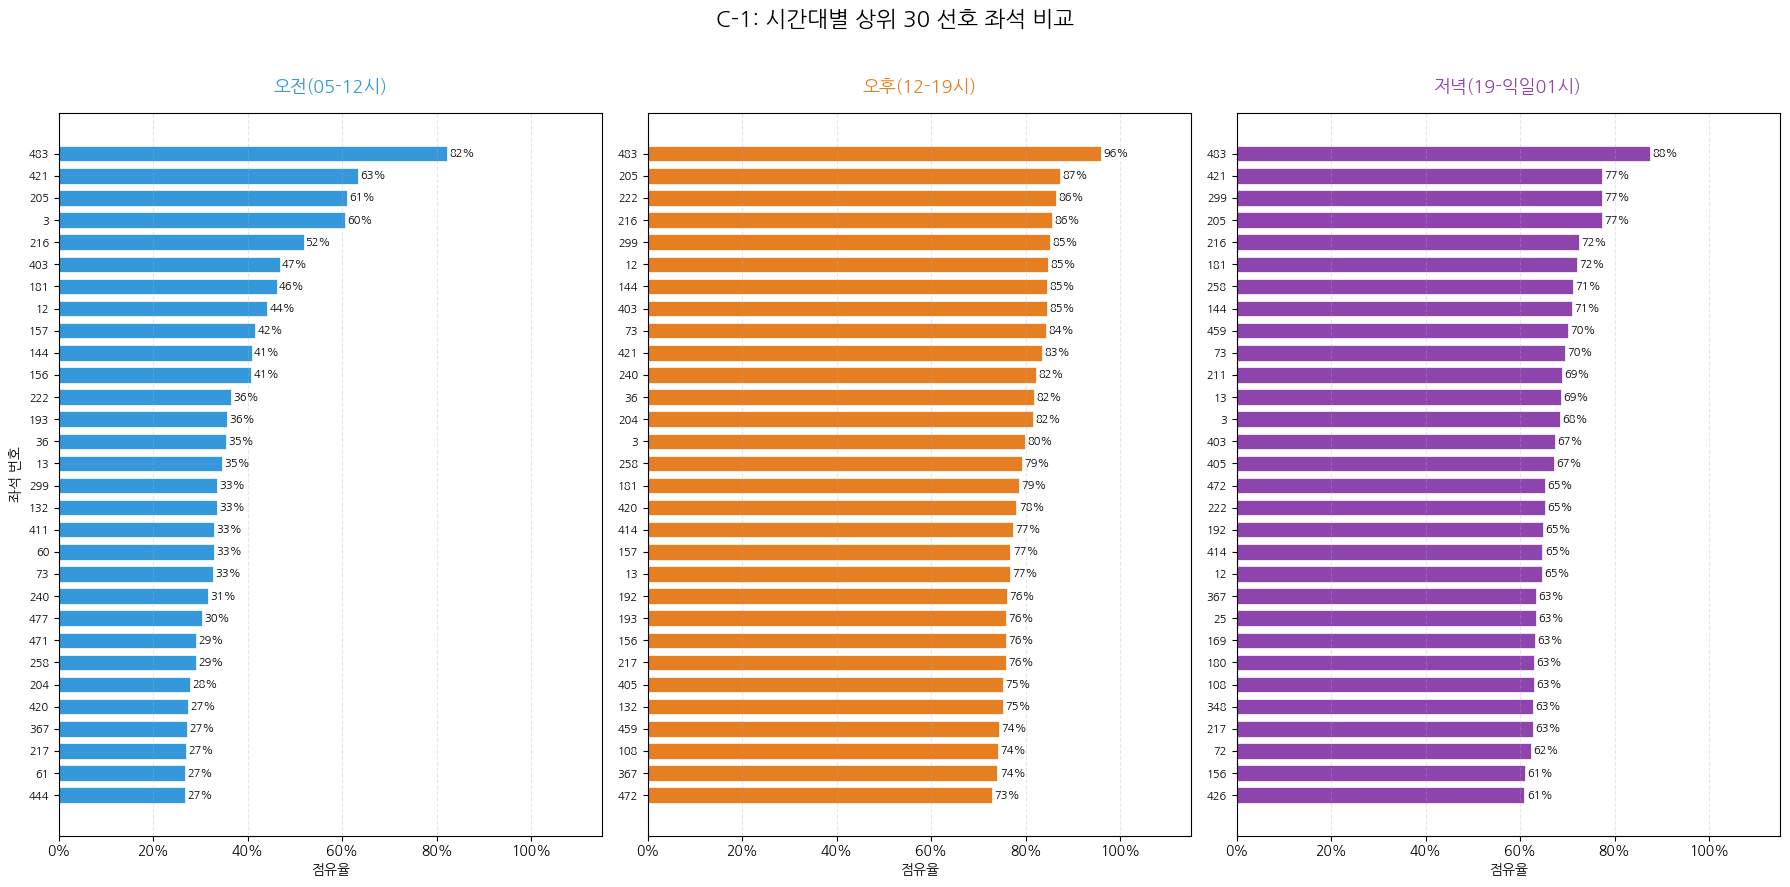

In [ ]:
# ============================================================
# [C-1] 시각화 1: 시간대별 상위 30 선호 좌석 비교 (막대그래프)
#      각 시간대에서 점유율이 높은 좌석 30개를 나란히 비교합니다.
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

# 1. 데이터 집계
def label_time_group(h):
    if 5 <= h < 12: return '오전(05-12시)'
    elif 12 <= h < 19: return '오후(12-19시)'
    elif 19 <= h <= 23 or h == 0: return '저녁(19-익일01시)'
    else: return '새벽(01-05시)'

df_seats['time_group'] = df_seats['hour'].apply(label_time_group)

seat_time_occ = df_seats.groupby(['time_group', 'code'])['isOccupied'].mean().reset_index()
seat_time_occ.columns = ['time_group', 'seat_code', 'occ_rate']

time_order_for_plot = ['오전(05-12시)', '오후(12-19시)', '저녁(19-익일01시)']
colors_map = {
    '오전(05-12시)':    '#3498db',
    '오후(12-19시)':    '#e67e22',
    '저녁(19-익일01시)': '#8e44ad'
}

# 분석 기준 설정
TOP_N = 30

# 2. 시각화 실행
# 30개를 출력하기 위해 높이를 확보하되, 폰트 크기를 조절하여 컴팩트하게 배치
fig, axes = plt.subplots(1, 3, figsize=(18, 9), sharey=False)

for ax, tg in zip(axes, time_order_for_plot):
    top_n = seat_time_occ[seat_time_occ['time_group'] == tg].nlargest(TOP_N, 'occ_rate')
    top_n = top_n.sort_values('occ_rate', ascending=True)

    bars = ax.barh(
        top_n['seat_code'].astype(str),
        top_n['occ_rate'],
        color=colors_map[tg],
        edgecolor='white',
        linewidth=0.5,
        height=0.7
    )

    # 텍스트 레이블 (데이터가 많으므로 크기 축소)
    for bar, val in zip(bars, top_n['occ_rate']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val*100:.0f}%', va='center', ha='left', fontsize=8)

    ax.set_title(tg, fontsize=13, fontweight='bold', color=colors_map[tg], pad=15)
    ax.set_xlabel('점유율', fontsize=10)
    ax.set_ylabel('좌석 번호' if tg == '오전(05-12시)' else '', fontsize=10)
    ax.set_xlim(0, 1.15)
    ax.tick_params(axis='y', labelsize=8) # 좌석 번호 폰트 크기 조정
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
    ax.grid(axis='x', alpha=0.3, linestyle='--')

fig.suptitle(f'C-1: 시간대별 상위 {TOP_N} 선호 좌석 비교', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**시간대별 상위 30 선호 좌석의 일치율 비교**

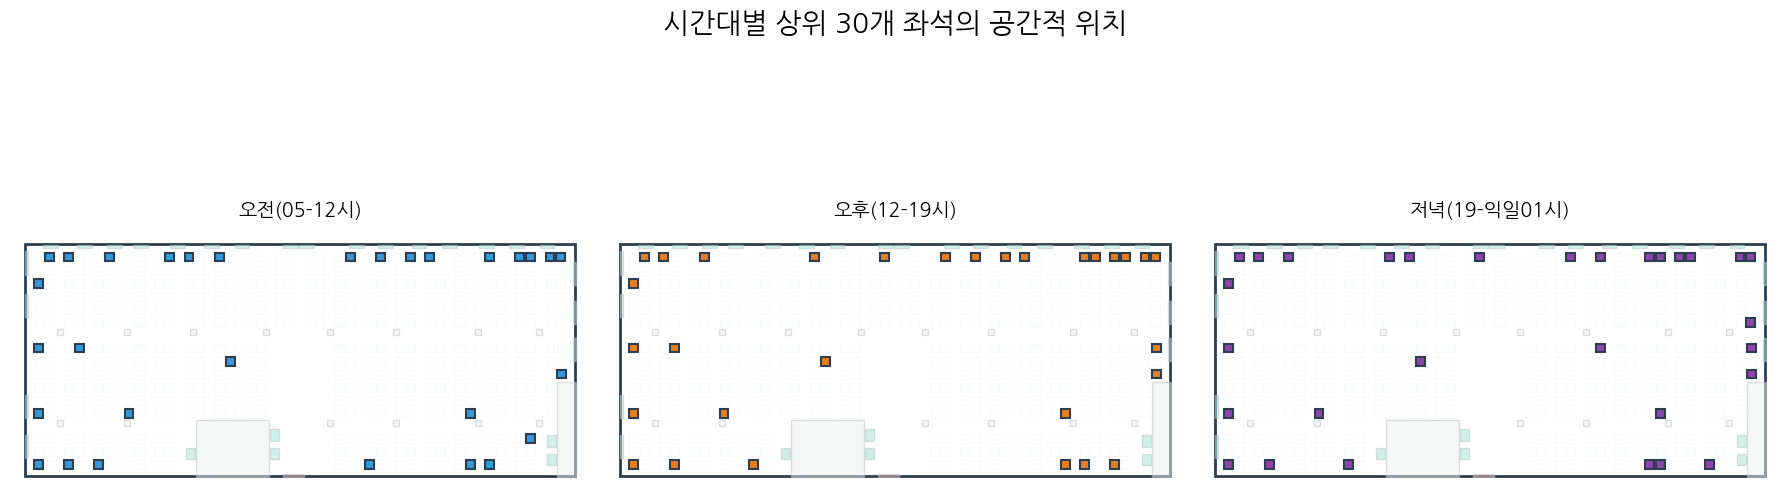

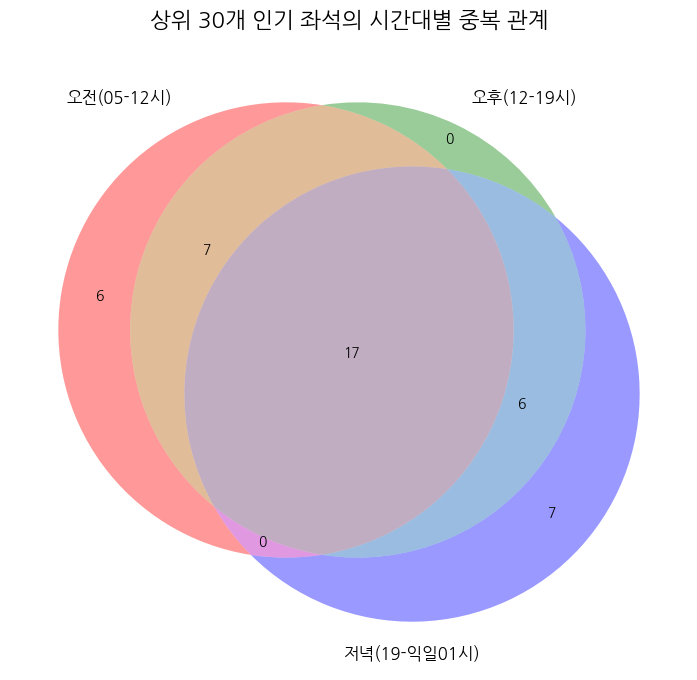


[인기 좌석 흐름 분석 요약]
- 하루 종일(오전/오후/저녁 공통) 인기 있는 '부동의 좌석': 17개
- 오전만 특별히 인기 있는 좌석: 6개
- 저녁에만 특별히 선호도가 상승하는 좌석: 7개


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import pandas as pd
import numpy as np
from matplotlib_venn import venn3
import warnings

# 경고 메시지 무시 설정 (벤 다이어그램 배치 관련)
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib_venn')

# 1. 시간대별 데이터 및 배치도 기본 정보 준비
time_groups = ['오전(05-12시)', '오후(12-19시)', '저녁(19-익일01시)']
colors_map = {'오전(05-12시)': '#3498db', '오후(12-19시)': '#e67e22', '저녁(19-익일01시)': '#8e44ad'}
TOP_N = 30

room = layout_data.get('room', {})
rw, rh = room.get('w', 1882), room.get('h', 795)
elements = layout_data.get('elements', [])

def draw_top_n_spatial(ax, tg):
    target_data = seat_time_occ[seat_time_occ['time_group'] == tg]
    if target_data.empty: return
    top_n_ids = target_data.nlargest(TOP_N, 'occ_rate')['seat_code'].astype(str).tolist()

    # 원본 배치도 스타일 유지 (ax.add_patch zorder 및 색상)
    ax.add_patch(patches.Rectangle((0, 0), rw, rh, linewidth=2, edgecolor='#2c3e50', facecolor='none', zorder=1))

    for el in elements:
        cat = el.get('category')
        x, y, w, h, r = el.get('x', 0), el.get('y', 0), el.get('w', 20), el.get('h', 20), el.get('r', 0)
        sid = str(el.get('id', ''))

        if cat != 'seat':
            # 원본 배경 요소 스타일
            face = '#ecf0f1' if cat in ['wall', 'pillar'] else '#f5b7b1' if cat == 'door' else '#a3e4d7'
            rect = patches.Rectangle((x, y), w, h, facecolor=face, edgecolor='#bdc3c7', alpha=0.5, zorder=2)
        else:
            is_top = sid in top_n_ids
            face = colors_map[tg] if is_top else '#f8f9f9'
            edge = '#2c3e50' if is_top else '#d5dbdb'
            alpha = 1.0 if is_top else 0.15
            rect = patches.Rectangle((x, y), w, h, facecolor=face, edgecolor=edge, linewidth=1.5 if is_top else 0.5, alpha=alpha, zorder=3 if is_top else 2)

        t = transforms.Affine2D().rotate_deg_around(x+w/2, y+h/2, r) + ax.transData
        rect.set_transform(t)
        ax.add_patch(rect)

    ax.set_xlim(-50, rw + 50)
    ax.set_ylim(-50, rh + 50)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')
    ax.set_title(f'{tg}', fontsize=14, fontweight='bold', pad=10)

# --- 1. 공간 분포 시각화 (원본 마진 및 타이틀 유지) ---
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 6))
for ax, tg in zip(axes1, time_groups):
    draw_top_n_spatial(ax, tg)

plt.suptitle(f'시간대별 상위 {TOP_N}개 좌석의 공간적 위치', fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# --- 2. 벤 다이어그램 (추가 분석 요소) ---
top_sets = {tg: set(seat_time_occ[seat_time_occ['time_group'] == tg].nlargest(TOP_N, 'occ_rate')['seat_code'].astype(str)) for tg in time_groups}

plt.figure(figsize=(10, 8))
v = venn3([top_sets[tg] for tg in time_groups], set_labels=time_groups)

if v.set_labels:
    for text in v.set_labels:
        if text:
            text.set_fontsize(12)
            text.set_fontweight('bold')

plt.title(f'상위 {TOP_N}개 인기 좌석의 시간대별 중복 관계', fontsize=16, fontweight='bold', pad=20)
plt.show()

# --- 3. 교집합 상세 분석 요약 ---
common_all = top_sets[time_groups[0]] & top_sets[time_groups[1]] & top_sets[time_groups[2]]
only_morning = top_sets[time_groups[0]] - (top_sets[time_groups[1]] | top_sets[time_groups[2]])
only_evening = top_sets[time_groups[2]] - (top_sets[time_groups[0]] | top_sets[time_groups[1]])

print(f"\n[인기 좌석 흐름 분석 요약]")
print(f"- 하루 종일(오전/오후/저녁 공통) 인기 있는 '부동의 좌석': {len(common_all)}개")
print(f"- 오전만 특별히 인기 있는 좌석: {len(only_morning)}개")
print(f"- 저녁에만 특별히 선호도가 상승하는 좌석: {len(only_evening)}개")

**전체 좌석의 평균 점유율과 상위 30석 좌석의 점유율 분석**

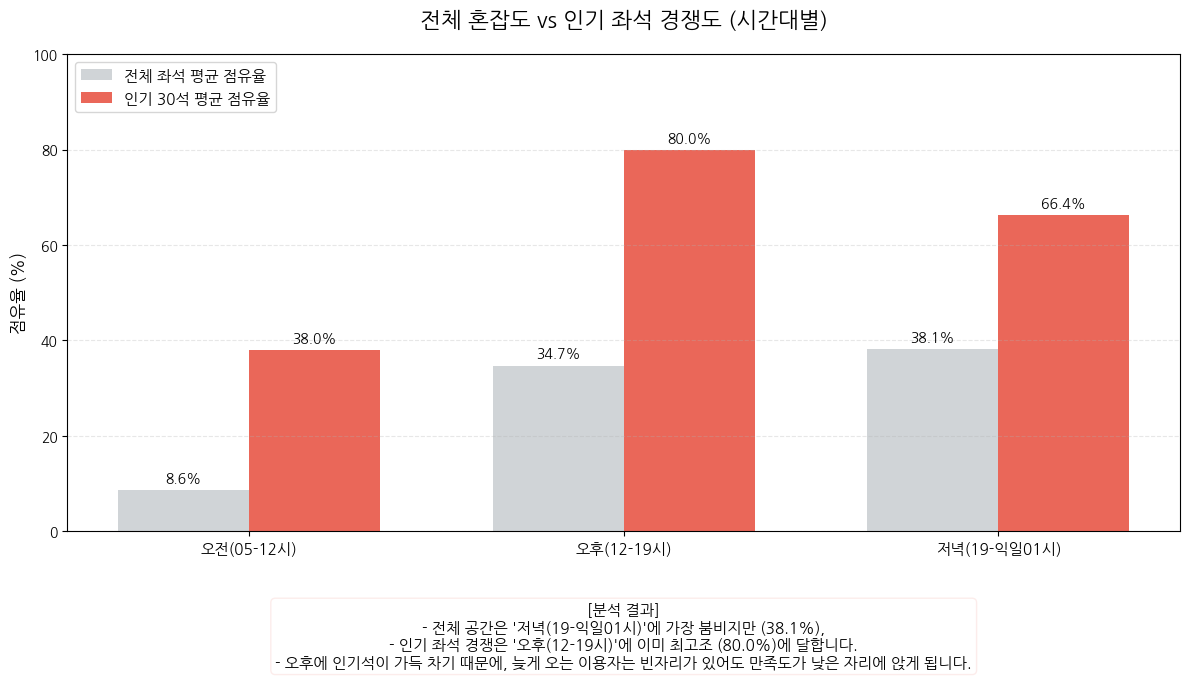

In [ ]:
# ============================================================
# [C-1] 심화 분석: 전체 평균 vs 상위 30석 점유율 역전 현상 분석
#     '전체 공간의 혼잡도'와 '인기 좌석의 경쟁도'가
#     시간대별로 어떻게 다르게 나타나는지 분석합니다.
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. 상위 30석 식별
overall_top_30 = seat_time_occ.groupby('seat_code')['occ_rate'].mean().nlargest(30).index

# 2. 시간대별 데이터 집계
# 전체 좌석 평균 점유율
overall_avg = seat_time_occ.groupby('time_group')['occ_rate'].mean().reindex(time_order_for_plot)
# 상위 30개 인기 좌석 평균 점유율
top_30_avg = seat_time_occ[seat_time_occ['seat_code'].isin(overall_top_30)].groupby('time_group')['occ_rate'].mean().reindex(time_order_for_plot)

# 3. 데이터프레임 구성
comparison = pd.DataFrame({
    '전체 좌석 평균': overall_avg,
    '상위 30석(인기석) 평균': top_30_avg
})

# 4. 시각화
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(time_order_for_plot))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['전체 좌석 평균'] * 100, width, label='전체 좌석 평균 점유율', color='#bdc3c7', alpha=0.7)
bars2 = ax.bar(x + width/2, comparison['상위 30석(인기석) 평균'] * 100, width, label='인기 30석 평균 점유율', color='#e74c3c', alpha=0.85)

# 수치 라벨링
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 스타일링
ax.set_title('전체 혼잡도 vs 인기 좌석 경쟁도 (시간대별)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(time_order_for_plot, fontsize=11)
ax.set_ylabel('점유율 (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# 분석 메모 추가
peak_time_overall = comparison['전체 좌석 평균'].idxmax()
peak_time_top30 = comparison['상위 30석(인기석) 평균'].idxmax()

analysis_text = (
    f"[분석 결과]\n"
    f"- 전체 공간은 '{peak_time_overall}'에 가장 붐비지만 ({comparison.loc[peak_time_overall, '전체 좌석 평균']*100:.1f}%),\n"
    f"- 인기 좌석 경쟁은 '{peak_time_top30}'에 이미 최고조 ({comparison.loc[peak_time_top30, '상위 30석(인기석) 평균']*100:.1f}%)에 달합니다.\n"
    f"- 오후에 인기석이 가득 차기 때문에, 늦게 오는 이용자는 빈자리가 있어도 만족도가 낮은 자리에 앉게 됩니다."
)

plt.text(0.5, -0.15, analysis_text, transform=ax.transAxes,
         ha='center', va='top', fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='#e74c3c', alpha=0.1))

plt.tight_layout()
plt.show()

**C. 시간대별 점유율 차이 분석 결과**

 **시간대별 점유율 현황**

| 시간대 | 평균 점유율 | 특징 |
|---|---|---|
| 오전 (05~12시) | 8.6% | 최저 혼잡 / 유휴 좌석 많음 |
| 오후 (12~19시) | 34.8% | 혼잡도 급증 시작 |
| 저녁 (19~01시) | 38.1% | 최고 혼잡 / 좌석 경쟁 심화 |

- **Kruskal-Wallis 검정**
  - H ≈ 2564.55
  - p < .001
  - **시간대 간 점유율 차이 유의**

- **사후 Mann-Whitney U 검정**
  - 오전 vs 오후 → 유의
  - 오전 vs 저녁 → 유의
  - 오후 vs 저녁 → 비유의
  - **오후 이후 혼잡 지속 패턴 확인**

 **인기 좌석 경쟁도 분석**

- 전체 평균 점유율 최고:
  - 저녁 38.1%

- **상위 30개 인기 좌석 점유율** 최고:
  - 오후 80.0%

- **인기 좌석 조기 포화 현상**
- 오후부터 선호 좌석 경쟁 심화
- **전체 빈자리 존재 ≠ 체감 좌석 부족 해소**


 **종합 해석**

- 오후부터 인기 좌석 중심 포화 시작
- **저녁 시간대 전체 혼잡도 극대화**
- 오전 시간대 유휴 자원 활용 가능성 존재
- **인기 좌석 회전율 관리 필요**
- **예약 시스템 유연화 필요성 시사**

---
### D. 시험 직전기간과 시험기간, 시험기간이 아닐 때의 차이 분석

**시험 직전기간, 시험기간, 시험기간 이후 별 열람실 이용 현황 및 패턴 분석**

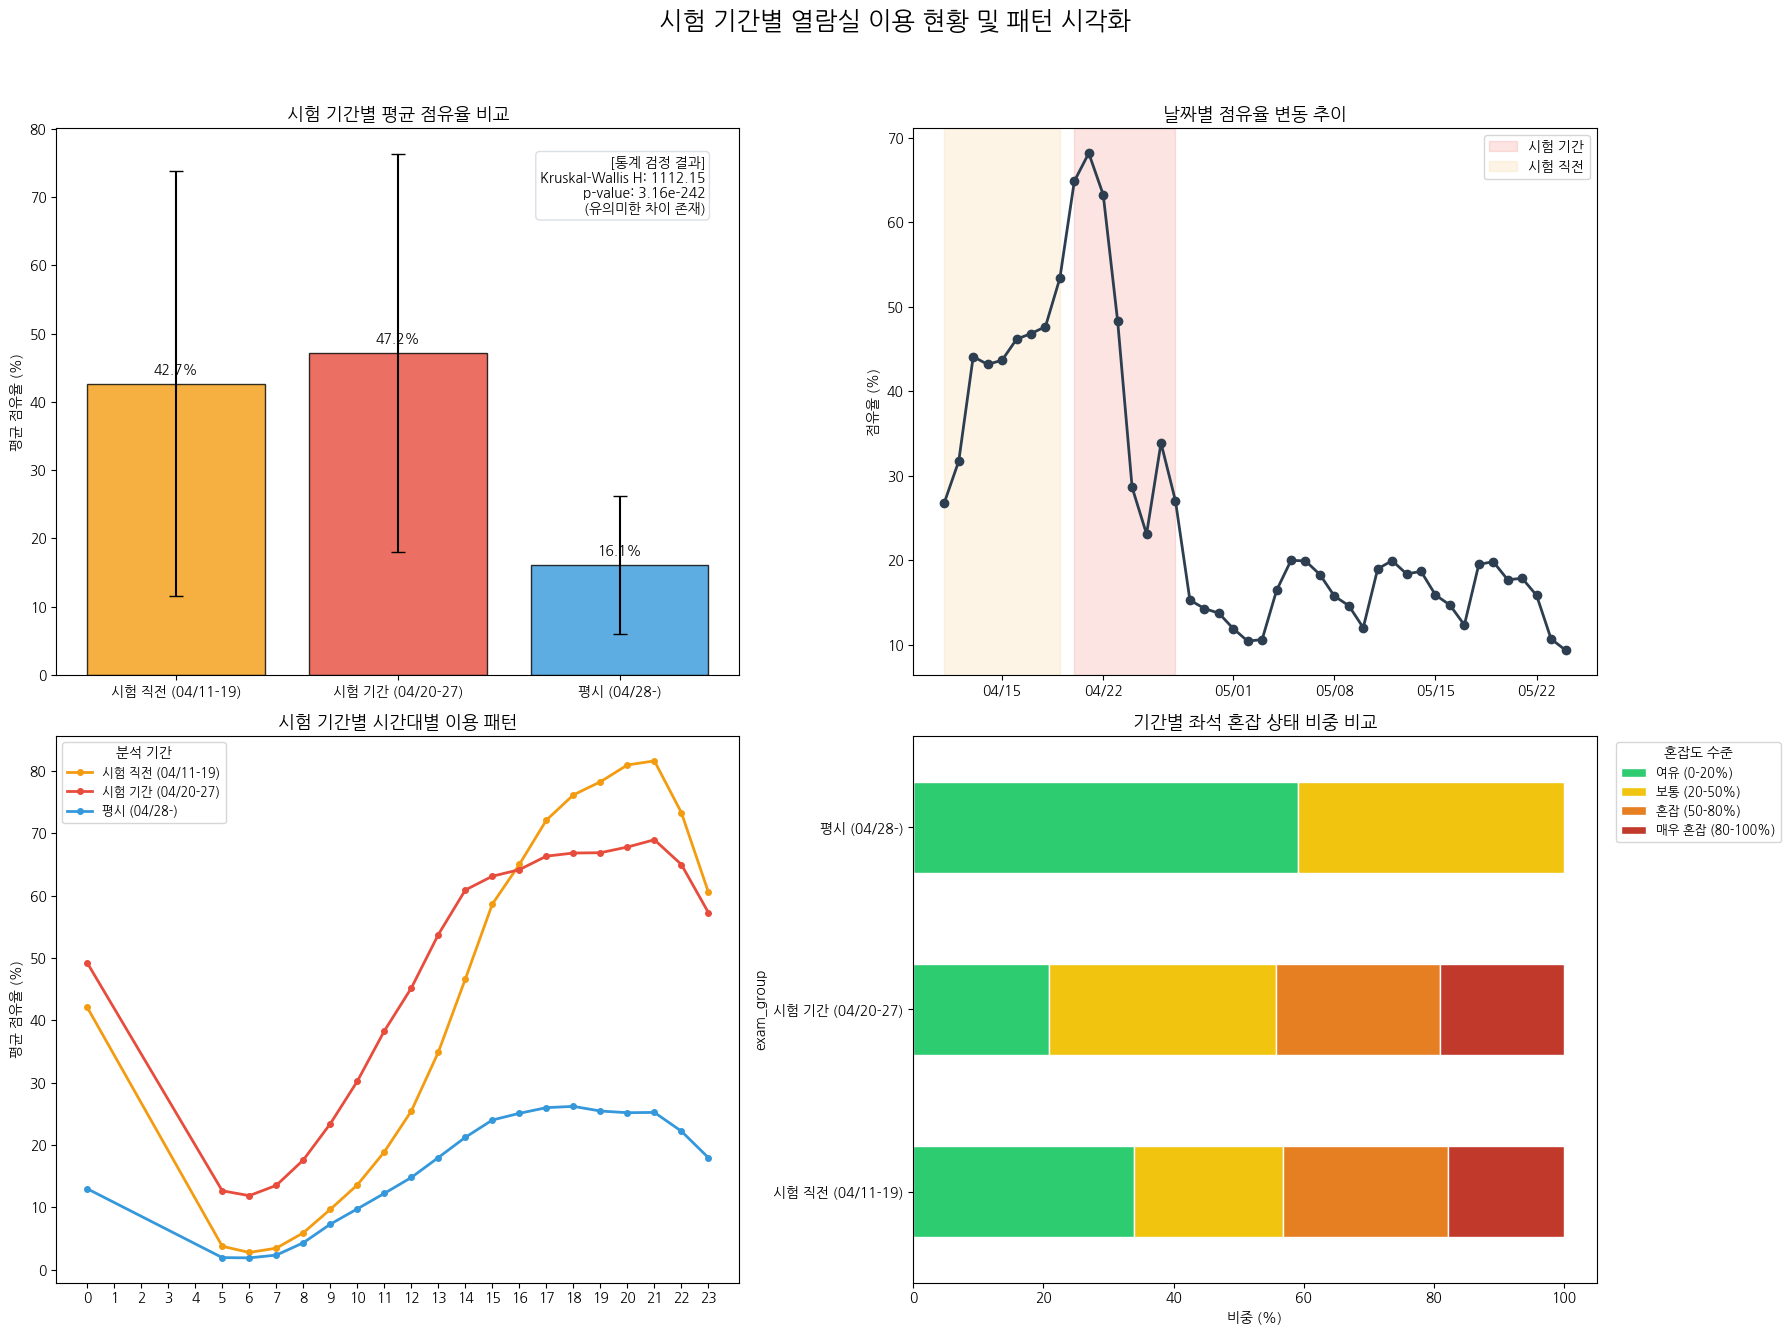

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# 1. 기간 분류 함수 정의
def classify_exam_period(dt):
    if pd.Timestamp('2026-04-11') <= dt < pd.Timestamp('2026-04-20'):
        return '시험 직전 (04/11-19)'
    elif pd.Timestamp('2026-04-20') <= dt <= pd.Timestamp('2026-04-27'):
        return '시험 기간 (04/20-27)'
    else:
        return '평시 (04/28-)'

# 2. 데이터 준비
snap_exam = df_seats.groupby('collected_at')['isOccupied'].mean().reset_index()
snap_exam.columns = ['collected_at', 'occ_rate']
snap_exam['exam_group'] = snap_exam['collected_at'].apply(classify_exam_period)

# 혼잡도 구간 분류 데이터 준비
def categorize_congestion(rate):
    if rate < 0.2: return '여유 (0-20%)'
    elif rate < 0.5: return '보통 (20-50%)'
    elif rate < 0.8: return '혼잡 (50-80%)'
    else: return '매우 혼잡 (80-100%)'

snap_exam['congestion_level'] = snap_exam['occ_rate'].apply(categorize_congestion)
level_order = ['여유 (0-20%)', '보통 (20-50%)', '혼잡 (50-80%)', '매우 혼잡 (80-100%)']
groups_order = ['시험 직전 (04/11-19)', '시험 기간 (04/20-27)', '평시 (04/28-)']

dist_data = snap_exam.groupby(['exam_group', 'congestion_level']).size().unstack(fill_value=0)
dist_pct = dist_data.div(dist_data.sum(axis=1), axis=0) * 100
dist_pct = dist_pct.reindex(index=groups_order, columns=level_order)

# 3. 기술통계 및 Kruskal-Wallis 검정
exam_stats = snap_exam.groupby('exam_group')['occ_rate'].agg(['count', 'mean', 'std']).reindex(groups_order)
groups = [snap_exam[snap_exam['exam_group'] == g]['occ_rate'] for g in exam_stats.index]
h_stat, p_val = stats.kruskal(*groups)

# 4. 시각화 (2x2 구성)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# (1) 기간별 평균 점유율 비교
ax1 = axes[0, 0]
colors = ['#f39c12', '#e74c3c', '#3498db']
bars = ax1.bar(exam_stats.index, exam_stats['mean'] * 100, color=colors, edgecolor='black', alpha=0.8)
ax1.errorbar(exam_stats.index, exam_stats['mean'] * 100, yerr=exam_stats['std'] * 100, fmt='none', c='black', capsize=5)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
ax1.set_title('시험 기간별 평균 점유율 비교', fontsize=13, fontweight='bold')
ax1.set_ylabel('평균 점유율 (%)')
sig_text = '유의미한 차이 존재' if p_val < 0.05 else '유의미한 차이 없음'
ax1.text(0.95, 0.95, f'[통계 검정 결과]\nKruskal-Wallis H: {h_stat:.2f}\np-value: {p_val:.2e}\n({sig_text})',
         transform=ax1.transAxes, ha='right', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#d0d7de'))

# (2) 날짜별 점유율 변동 추이
ax2 = axes[0, 1]
daily_occ = snap_exam.set_index('collected_at')['occ_rate'].resample('D').mean() * 100
ax2.plot(daily_occ.index, daily_occ.values, marker='o', linestyle='-', color='#2c3e50', linewidth=2)
ax2.axvspan(pd.Timestamp('2026-04-20'), pd.Timestamp('2026-04-27'), color='#e74c3c', alpha=0.15, label='시험 기간')
ax2.axvspan(pd.Timestamp('2026-04-11'), pd.Timestamp('2026-04-19'), color='#f39c12', alpha=0.1, label='시험 직전')
ax2.set_title('날짜별 점유율 변동 추이', fontsize=13, fontweight='bold')
ax2.set_ylabel('점유율 (%)')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: pd.Timestamp(x, unit='d').strftime('%m/%d')))
ax2.legend()

# (3) 시간대별 하루 이용 패턴 비교
ax3 = axes[1, 0]
snap_hourly = df_seats.groupby(['collected_at', 'hour'])['isOccupied'].mean().reset_index()
snap_hourly['exam_group'] = snap_hourly['collected_at'].apply(classify_exam_period)
hourly_pattern = snap_hourly.groupby(['exam_group', 'hour'])['isOccupied'].mean().unstack(level=0) * 100
colors_exam = {'시험 직전 (04/11-19)': '#f39c12', '시험 기간 (04/20-27)': '#e74c3c', '평시 (04/28-)': '#3498db'}
for group in groups_order:
    if group in hourly_pattern.columns:
        ax3.plot(hourly_pattern.index, hourly_pattern[group], label=group, color=colors_exam[group], marker='o', markersize=4, linewidth=2)
ax3.set_title('시험 기간별 시간대별 이용 패턴', fontsize=13, fontweight='bold')
ax3.set_xticks(range(0, 24))
ax3.set_ylabel('평균 점유율 (%)')
ax3.legend(title='분석 기간', fontsize=9)

# (4) 기간별 좌석 혼잡 상태 비중 비교
ax4 = axes[1, 1]
dist_pct.plot(kind='barh', stacked=True, ax=ax4, color=['#2ecc71', '#f1c40f', '#e67e22', '#c0392b'], edgecolor='white')
ax4.set_title('기간별 좌석 혼잡 상태 비중 비교', fontsize=13, fontweight='bold')
ax4.set_xlabel('비중 (%)')
ax4.legend(title='혼잡도 수준', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.suptitle('시험 기간별 열람실 이용 현황 및 패턴 시각화', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**시험 직전기간, 시험기간, 시험기간 이후 기간 각각의 요일별 이용 밀도 분석**

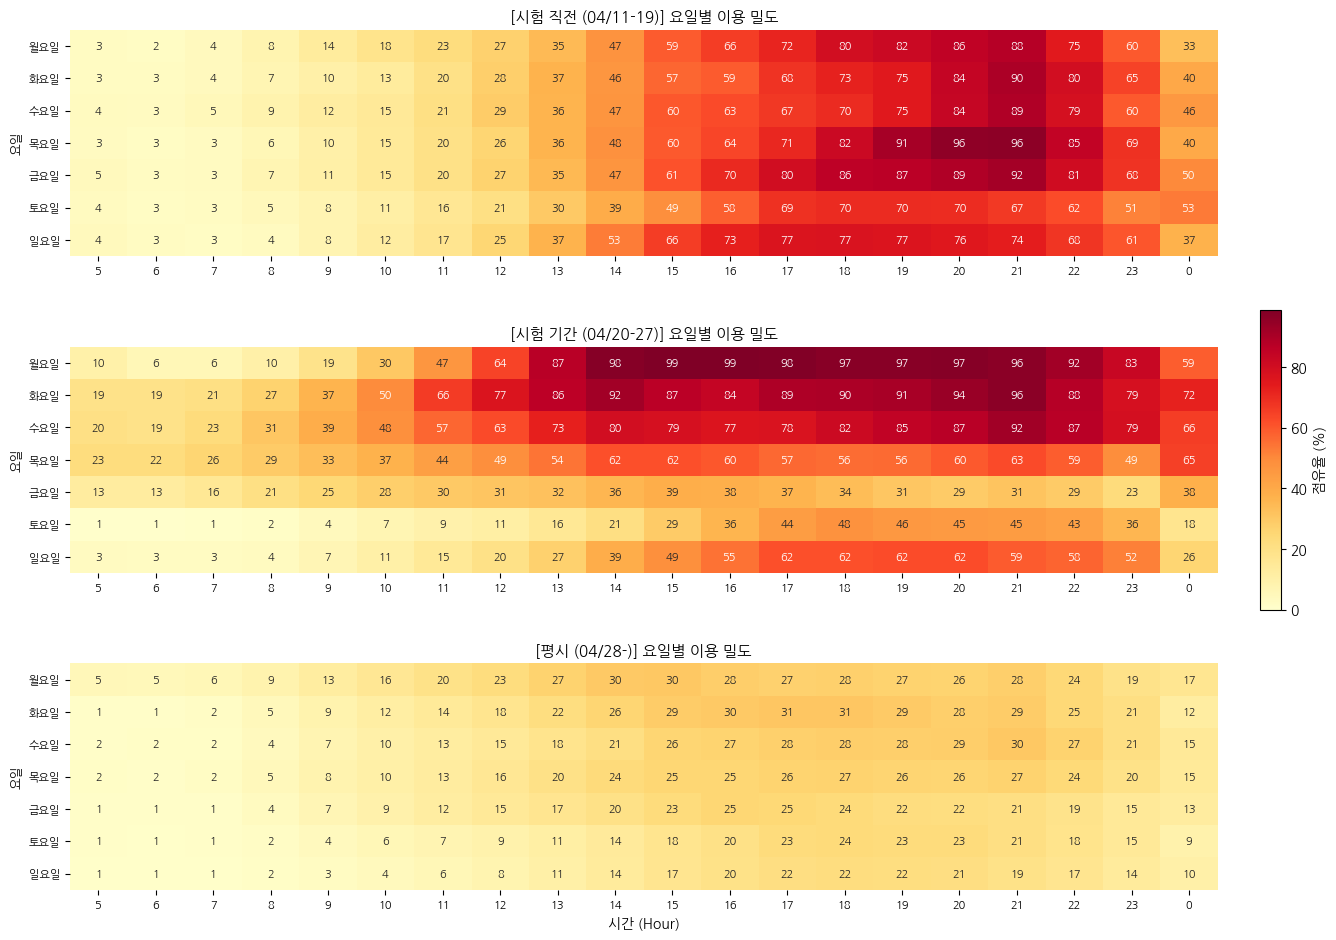

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 데이터 준비: 요일 및 기간 분류
snap_hourly = df_seats.groupby(['collected_at', 'hour'])['isOccupied'].mean().reset_index()
snap_hourly['exam_group'] = snap_hourly['collected_at'].apply(classify_exam_period)
snap_hourly['day_of_week'] = snap_hourly['collected_at'].dt.day_name()

# 요일 한글 매핑 및 정렬
days_map = {
    'Monday': '월요일', 'Tuesday': '화요일', 'Wednesday': '수요일',
    'Thursday': '목요일', 'Friday': '금요일', 'Saturday': '토요일', 'Sunday': '일요일'
}
snap_hourly['day_of_week_ko'] = snap_hourly['day_of_week'].map(days_map)
days_order_ko = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']

target_hours = list(range(5, 24)) + [0]
groups_order = ['시험 직전 (04/11-19)', '시험 기간 (04/20-27)', '평시 (04/28-)']

# 시각화 구성 (전체 크기를 줄여서 스크롤 방지)
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# [통일된 색상 스케일 계산]
pivots = []
for group_name in groups_order:
    group_data = snap_hourly[snap_hourly['exam_group'] == group_name]
    if not group_data.empty:
        p = group_data.pivot_table(index='day_of_week_ko', columns='hour', values='isOccupied', aggfunc='mean')
        p = p.reindex(index=days_order_ko, columns=target_hours)
        pivots.append(p)

all_max_val = max([p.max().max() for p in pivots]) * 100 if pivots else 100

# [분석 1] 기간별 요일/시간 히트맵
for i, group_name in enumerate(groups_order):
    ax = axes[i]
    group_data = snap_hourly[snap_hourly['exam_group'] == group_name]

    if not group_data.empty:
        pivot = group_data.pivot_table(index='day_of_week_ko', columns='hour', values='isOccupied', aggfunc='mean')
        pivot = pivot.reindex(index=days_order_ko, columns=target_hours)

        sns.heatmap(pivot * 100, cmap='YlOrRd', annot=True, fmt='.0f', ax=ax,
                    vmin=0, vmax=all_max_val, cbar=False, annot_kws={'size': 8})

    ax.set_title(f'[{group_name}] 요일별 이용 밀도', fontsize=11, fontweight='bold')
    ax.set_xlabel('시간 (Hour)' if i == 2 else '')
    ax.set_ylabel('요일', fontsize=9)
    ax.tick_params(labelsize=8)

# 공통 컬러바
mappable = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=0, vmax=all_max_val))
mappable.set_array([])
cbar_ax = fig.add_axes([0.93, 0.35, 0.015, 0.3])
fig.colorbar(mappable, cax=cbar_ax, label='점유율 (%)')

# 수동 간격 조정
fig.subplots_adjust(left=0.08, right=0.9, top=0.93, bottom=0.07, hspace=0.4)
plt.show()

**분석 기간별 공간 이용 패턴 비교 분석**

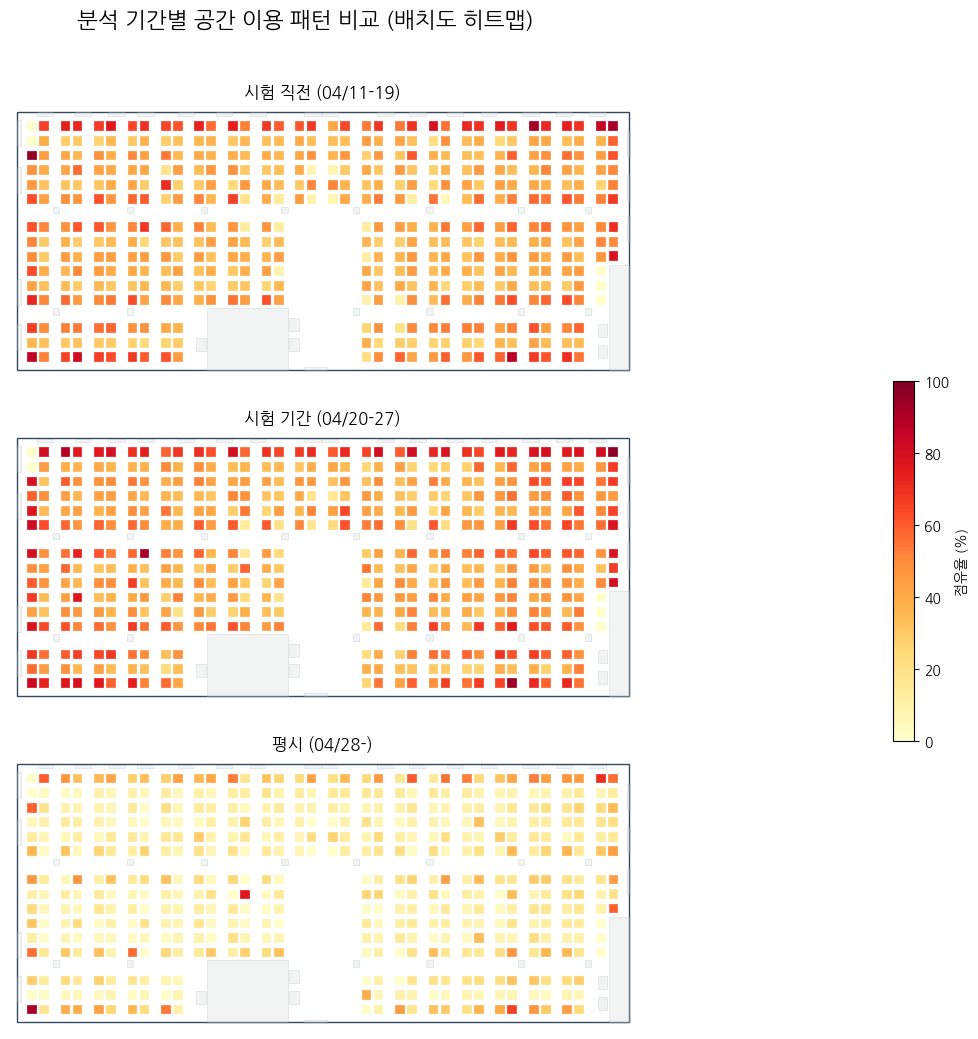

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import matplotlib.ticker as mticker
import pandas as pd

# 0. 데이터 준비: df_seats에 exam_group 컬럼 추가
def classify_exam_period(dt):
    if pd.Timestamp('2026-04-11') <= dt < pd.Timestamp('2026-04-20'):
        return '시험 직전 (04/11-19)'
    elif pd.Timestamp('2026-04-20') <= dt <= pd.Timestamp('2026-04-27'):
        return '시험 기간 (04/20-27)'
    else:
        return '평시 (04/28-)'

# 'collected_at' 컬럼이 이미 datetime 형식이 아닌 경우 변환 후 적용
if not pd.api.types.is_datetime64_any_dtype(df_seats['collected_at']):
    df_seats['collected_at'] = pd.to_datetime(df_seats['collected_at'])

df_seats['exam_group'] = df_seats['collected_at'].apply(classify_exam_period)

# 1. 기간별 배치도 히트맵 비교 시각화 함수 정의
def draw_period_heatmap(ax, period_name, seat_stats, layout_data):
    room = layout_data.get('room', {})
    rw, rh = room.get('w', 1882), room.get('h', 795)
    elements = layout_data.get('elements', [])

    ax.add_patch(patches.Rectangle((0, 0), rw, rh, linewidth=1, edgecolor='#34495e', facecolor='none', zorder=1))

    for el in elements:
        cat = el.get('category')
        if cat == 'seat': continue
        x, y, w, h, r = el.get('x',0), el.get('y',0), el.get('w',20), el.get('h',20), el.get('r',0)
        rect = patches.Rectangle((x, y), w, h, facecolor='#d5dbdb', edgecolor='#95a5a6', alpha=0.3, linewidth=0.5)
        t = transforms.Affine2D().rotate_deg_around(x+w/2, y+h/2, r) + ax.transData
        rect.set_transform(t)
        ax.add_patch(rect)

    period_seats = seat_stats[seat_stats['exam_group'] == period_name]
    norm = plt.Normalize(vmin=0, vmax=100)
    cmap = plt.cm.YlOrRd

    for el in elements:
        if el.get('category') != 'seat': continue
        sid = str(el.get('id'))
        x, y, w, h, r = el.get('x',0), el.get('y',0), el.get('w',20), el.get('h',20), el.get('r',0)

        # 해당 기간에 좌석 데이터가 있는지 확인
        mask = period_seats['code'] == sid
        occ_val = period_seats[mask]['isOccupied'].iloc[0] * 100 if mask.any() else 0

        rect = patches.Rectangle((x, y), w, h, facecolor=cmap(norm(occ_val)), edgecolor='white', linewidth=0.2, zorder=3)
        t = transforms.Affine2D().rotate_deg_around(x+w/2, y+h/2, r) + ax.transData
        rect.set_transform(t)
        ax.add_patch(rect)

    ax.set_xlim(-20, rw + 20); ax.set_ylim(-20, rh + 20)
    ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
    ax.set_title(f'{period_name}', fontsize=12, fontweight='bold')

# 2. 기간별 좌석별 평균 점유율 계산 및 시각화 실행
seat_period_stats = df_seats.groupby(['exam_group', 'code'])['isOccupied'].mean().reset_index()

fig_hm, axes_hm = plt.subplots(3, 1, figsize=(14, 12))
groups_order = ['시험 직전 (04/11-19)', '시험 기간 (04/20-27)', '평시 (04/28-)']

for i, g_name in enumerate(groups_order):
    draw_period_heatmap(axes_hm[i], g_name, seat_period_stats, layout_data)

sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=0, vmax=100))
cbar_ax = fig_hm.add_axes([0.92, 0.35, 0.015, 0.3])
fig_hm.colorbar(sm, cax=cbar_ax, label='점유율 (%)')

plt.suptitle('분석 기간별 공간 이용 패턴 비교 (배치도 히트맵)', fontsize=16, fontweight='bold', y=0.96)
plt.subplots_adjust(hspace=0.2, right=0.9)
plt.show()

**분석 기간별 예약량 및 회전율 비교 분석**

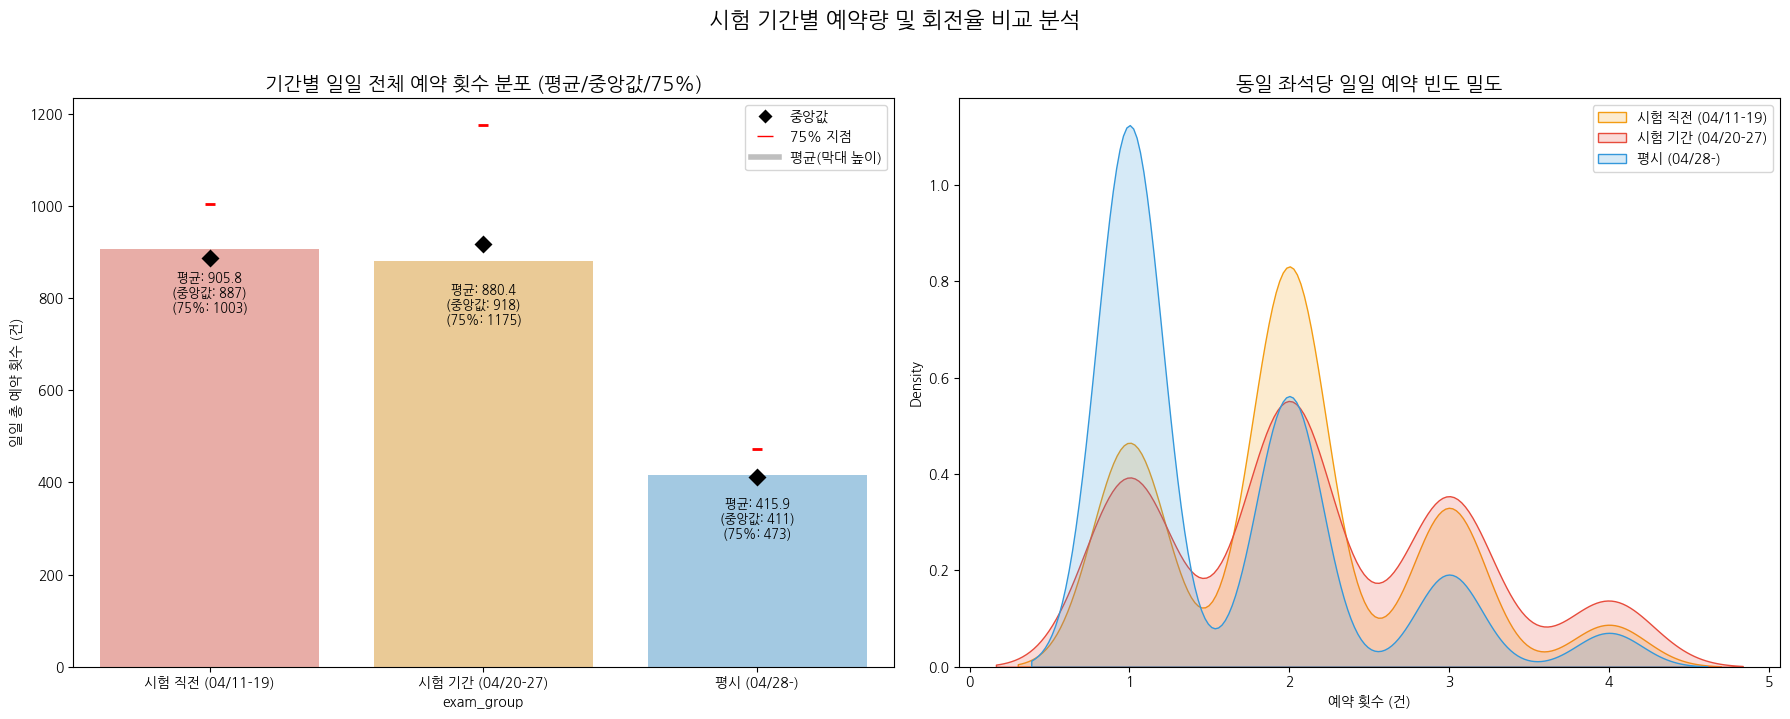

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_reservations_by_period(df_seats):
    # 1. 데이터 준비
    df_analysis = df_seats.copy()
    df_analysis['date'] = df_analysis['collected_at'].dt.date

    daily_res_counts = (
        df_analysis[df_analysis['isOccupied'] == True]
        .groupby(['exam_group', 'date', 'code'])['chargeTime']
        .nunique()
        .reset_index()
    )
    daily_res_counts.columns = ['exam_group', 'date', 'code', 'res_count']

    total_daily_res = (
        daily_res_counts.groupby(['exam_group', 'date'])['res_count']
        .sum()
        .reset_index()
    )

    # 시각화 설정
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    colors = ['#f39c12', '#e74c3c', '#3498db']
    order = ['시험 직전 (04/11-19)', '시험 기간 (04/20-27)', '평시 (04/28-)']

    # [좌측] 기간별 일일 전체 예약 횟수 분포
    sns.barplot(
        x='exam_group', y='res_count', data=total_daily_res, order=order,
        palette=colors, hue='exam_group', legend=False, ax=axes[0],
        errorbar=None, alpha=0.5
    )

    # 1. 중앙값(Median) 표시 - 다이아몬드
    sns.pointplot(
        x='exam_group', y='res_count', data=total_daily_res, order=order,
        color='black', markers='D', linestyle='none', estimator=np.median,
        errorbar=None, ax=axes[0]
    )

    # 2. 75% 백분위수(Q3) 표시
    sns.pointplot(
        x='exam_group', y='res_count', data=total_daily_res, order=order,
        color='red', markers='_', linestyle='none',
        estimator=lambda x: np.percentile(x, 75),
        errorbar=None, ax=axes[0]
    )

    axes[0].set_title('기간별 일일 전체 예약 횟수 분포 (평균/중앙값/75%)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('일일 총 예약 횟수 (건)')

    # 수치 라벨 및 범례 추가
    stats_data = total_daily_res.groupby('exam_group')['res_count'].agg([
        'mean',
        'median',
        ('q75', lambda x: np.percentile(x, 75))
    ]).reindex(order)

    for i, (idx, row) in enumerate(stats_data.iterrows()):
        # 수치 라벨 형식 통일 (평균, 중앙값, 75%)
        label_text = f'평균: {row["mean"]:.1f}\n(중앙값: {row["median"]:.0f})\n(75%: {row["q75"]:.0f})'
        axes[0].text(i, row['mean'] - 50, label_text,
                     ha='center', va='top', fontsize=9, fontweight='bold', color='black')

    # 범례 커스텀 생성
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='D', color='w', label='중앙값', markerfacecolor='black', markersize=8),
        Line2D([0], [0], marker='_', color='w', label='75% 지점', markerfacecolor='red', markeredgecolor='red', markersize=12),
        Line2D([0], [0], color='gray', lw=4, alpha=0.5, label='평균(막대 높이)')
    ]
    axes[0].legend(handles=legend_elements, loc='upper right')

    # [우측] KDE Plot
    for i, group in enumerate(order):
        group_data = daily_res_counts[daily_res_counts['exam_group'] == group]['res_count']
        if not group_data.empty:
            sns.kdeplot(group_data, label=group, color=colors[i], ax=axes[1], fill=True, alpha=0.2, bw_adjust=1.5)

    axes[1].set_title('동일 좌석당 일일 예약 빈도 밀도', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('예약 횟수 (건)')
    axes[1].legend()

    plt.suptitle('시험 기간별 예약량 및 회전율 비교 분석', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# 분석 실행
analyze_reservations_by_period(df_seats)

**D. 시험 직전·시험기간·평시 비교 분석 결과**

**기간별 평균 점유율**

| 기간 구분 | 평균 점유율 | 특징 |
|---|---|---|
| 평시 | 16.1% | 낮은 혼잡도 / 여유 좌석 많음 |
| 시험 직전 | 42.7% | 혼잡 급증 / 이용 집중 시작 |
| 시험 기간 | 47.2% | 최고 혼잡 / 장시간 점유 심화 |

- 시험 관련 기간 혼잡도
  - **평시 대비 약 2.6~2.9배 증가**

- **Kruskal-Wallis 검정**
  - H ≈ 1112.15
  - p < .001
  - 기간별 점유율 차이 유의


**시간대별 이용 패턴 변화**

- 평시
  - 오후 피크 이후 저녁 완만 감소
  - 일반적인 일일 이용 패턴ㅁ

- 시험 직전·시험 기간
  - **저녁(19시 이후) 고점유 유지**
  - 60~80% 이상 지속
  - 밤샘 이용·장시간 체류 증가


**혼잡도 변화**

- 평시
  - 50% 이상 혼잡 구간 드묾

- 시험 기간
  - 전체 스냅샷 약 44% 이상
  - **‘혼잡’·‘매우 혼잡’ 상태 도달**
  
**동일 좌석 예약 빈도 분석**

- 평시
  - 동일 좌석 1회 이용 비중 높음

- 시험 직전·시험 기간
  - 2~4회 이상 다회 예약 증가
  - **동일 좌석 반복 연장 사용 증가**

- 회전율
  - 단순 이용자 교체 증가 X
  - 기존 이용자의 장시간 점유 경향 강화
  - 회전율 감소 가능성 시사


**요일별 패턴 변화**

- 시험 직전 기간
  - **주말 점유율 급증**
  - ‘벼락치기’ 이용 패턴 관찰


**종합 해석**

- **시험 기간 → 이용 시간대 확장 + 장시간 점유 동시 발생**
- **인기 좌석 경쟁 심화**
- 체감 좌석 부족 현상 증가
- 자리비움 문제 영향 확대 가능성
- **예약·회전율 관리 필요성 시사**

---
### 데이터 분석 결과 종합 (A·B·C·D)
| 분석 | 결과 | 시사점 |
|---|---|---|
| **A. 좌석 이용 편중** | **χ² ≈ 170,293.6 (p < .001)**, Gini = 0.268 (중간), **과이용 171**·저이용 275개, 좌석번호 ρ = +0.005 (무관) | **좌석 부족 문제**는 전체 좌석 수 부족보다 **특정 위치 좌석에 대한 선호 집중 현상**과 더 관련됨 |
| **B. 위치관계** | **가장자리 점수 ρ = 0.45, 출입문 거리 ρ = 0.28**, 창문 거리 ρ = -0.22 (모두 p < .001), 기둥 거리 무관 | 학생들은 벽면·가장자리·출입문에서 먼 좌석처럼 **심리적 안정감과 독립성이 높은 공간**을 선호함 |
| **C. 시간대별 점유율** | **저녁(38.1%)** > 오후(34.8%) > 오전(8.6%), 인기 30석은 오후(80.0%)에 이미 피크 | 실제 좌석 경쟁은 전체 혼잡 최고 시점보다 더 이른 오후부터 시작되며, **인기 좌석 조기 포화가 체감 혼잡을 유발함** |
| **D. 시험기간 분석** | **시험 기간(47.2%) > 시험 직전(42.7%)** > 평시(16.1%), 시험 시기 혼잡 이상 비중 44% | 시험 기간에는 단순 이용자 증가뿐 아니라 **장시간 점유·밤샘 이용** 증가로 **좌석 회전율이 낮아지며 체감 좌석 부족**이 심화됨 |

---
## 설문 데이터 분석

실측 데이터는 **행동(어디에·얼마나 오래 앉았는가)** 을 보여주지만, **왜 그렇게 행동했는지** 까지는 설명하지 못합니다.  
한국외국어대학교 학생 **160명** 을 대상으로 한 설문을 결합해, 다음 **6가지**를 검증했습니다.

| 결합 분석 | 실측 분석 연결 | 핵심 질문 |
|----|----|----|
| A. 응답자 프로파일 | 공통 | 누가 답했는가 |
| B. 인식 vs 행동 (좌석·환경) | **A·B 분석 결과** | 좋아한다고 말한 자리와 실제로 앉는 자리가 같은가 |
| C. 시간 인식 vs 행동 | **C·D 분석 결과** | 자기보고 이용시간이 실측과 일치하는가 |
| D. 시험기간 자기보고 | **D 분석 결과** | 정말 시험기간에 더 자주 오는가 |
| E. 자리비움 행태 | **D 분석의 회전율 해석** | "빈자리는 보이는데 왜 부족한가"의 직접적 답 |
| F. 시스템 만족도·개선안 | **정책 제안 슬라이드** | 이용자가 직접 제시한 해법 |

위 6가지 결합을 통해 실측만으로는 보이지 않는 두 가지 격차 — **"점유 ≠ 사용"** 과 **"의식 ≠ 행동"** — 을 정량적으로 확인합니다.

In [ ]:
# ── 설문 데이터 다운로드 ─────────────────────────────────────────
import gdown
import pandas as pd
from pathlib import Path

file_id = '1Pbve-k6vNlzipVaBq5r9sChuDJQsYk6c'
data_dir = Path('/content') if Path('/content').exists() else Path('.')
output_path_survey = str(data_dir / 'library_survey.csv')

gdown.download(
    f'https://drive.google.com/uc?id={file_id}',
    output_path_survey,
    quiet=False,
)

print("설문 데이터 다운로드 완료")

# ── 로드 ─────────────────────────────────────────────────────────
survey = pd.read_csv(output_path_survey)
print(f'응답자 수: {len(survey)}명, 컬럼 수: {len(survey.columns)}개')
display(survey.head(2))

Downloading...
From: https://drive.google.com/uc?id=1Pbve-k6vNlzipVaBq5r9sChuDJQsYk6c
To: /content/library_survey.csv
100%|██████████| 97.0k/97.0k [00:00<00:00, 31.9MB/s]

설문 데이터 다운로드 완료
응답자 수: 160명, 컬럼 수: 29개


,타임스탬프,지난 일 년 동안 우리 학교 도서관 열람실을 이용한 적이 있습니까?,평소 도서관의 열람실을 얼마나 자주 이용하시나요?,주로 어느 시간대에 이용하시나요? (해당되는 것 모두 선택),1회 방문 시 평균적으로 얼마나 머무르시나요?,시험 기간(중간·기말)에 이용 빈도가 평소보다 어떻게 달라지나요?,(선택) 시험기간에 이용빈도가 위와 같은 이유는 무엇인가요?,"1열람실 좌석은 크게 ‘일반 좌석’, ‘칸막이 좌석’, ‘장애인석’ 3종으로 구성됩니다. 본인이 평소 가장 선호하는 좌석 종류는 무엇인가요?",방금 선택한 좌석 종류를 선호하는 이유를 모두 골라주세요.,다음 좌석 환경 요소가 본인 만족도에 얼마나 영향을 주나요? [콘센트 접근성],...,현재 도서관 좌석 시스템(체크인/체크아웃·예약·시간 충전)에 얼마나 만족하시나요?,현재 시스템에서 가장 불편한 점을 모두 선택해주세요.,"‘일정 시간 자리를 비우면 자동으로 좌석이 반납되는 정책’을 도입한다면, 적정 시간은 얼마라고 생각하시나요?",다음 개선 아이디어 중 가장 도움이 될 것 같은 순서로 1·2·3순위를 골라주세요. [1순위],다음 개선 아이디어 중 가장 도움이 될 것 같은 순서로 1·2·3순위를 골라주세요. [2순위],다음 개선 아이디어 중 가장 도움이 될 것 같은 순서로 1·2·3순위를 골라주세요. [3순위],(선택) 이외에 구체적으로 제안하고 싶은 도서관 좌석 시스템 개선안이 있다면 자유롭게 적어주세요.,개인정보 제공 및 경품 추첨 참여에 동의하십니까?,"경품 발송을 위한 정보를 입력해 주세요. (성함, 전화번호)",@
0,2026. 5. 13 오후 2:56:34,예,월 1~3회,"오후 (12시–19시), 저녁 (19시–익일1시)",4–6시간,훨씬 자주(2배 이상),NaN,일반 좌석 (개방형 좌석),"공간감·개방감이 좋아서, 창가·채광이 좋아서",3,...,3,자리비움 시 자동 반납이 안 됨,90분,미사용 좌석 자동 반납,예약 노쇼 패널티,실시간 좌석 현황,NaN,동의합니다,이다은 010-9216-4198,NaN
1,2026. 5. 13 오후 2:56:58,예,월 1~3회,저녁 (19시–익일1시),2–4시간,비슷함,NaN,일반 좌석 (개방형 좌석),"공간감·개방감이 좋아서, 조명이 밝아서, 친구와 같이 앉을 수 있어서",3,...,4,딱히 없음,45분,실시간 좌석 현황,혼잡 시간 알림,단시간 이용 구역,NaN,동의합니다,"말리카 , 010-5873-2170",NaN


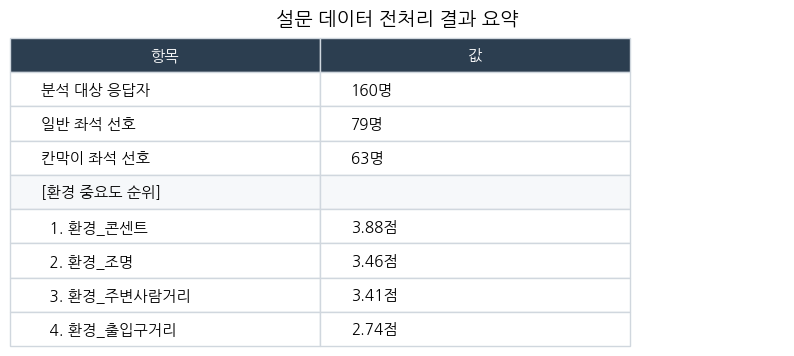

In [ ]:
# ── 설문 데이터 전처리 및 요약 시각화 ───────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from scipy import stats

survey = pd.read_csv(output_path_survey)

# 1) 짧은 컬럼명 매핑
col_map = {
    survey.columns[1]: '이용경험',
    survey.columns[2]: '이용빈도',
    survey.columns[3]: '주이용시간대',
    survey.columns[4]: '평균체류',
    survey.columns[5]: '시험기간변화',
    survey.columns[6]: '시험기간이유',
    survey.columns[7]: '선호좌석',
    survey.columns[8]: '선호이유',
    survey.columns[9]:  '환경_콘센트',
    survey.columns[10]: '환경_조명',
    survey.columns[11]: '환경_출입구거리',
    survey.columns[12]: '환경_주변사람거리',
    survey.columns[13]: '선호자리없을때',
    survey.columns[14]: '모션데스크인지',
    survey.columns[15]: '자리비움시간',
    survey.columns[16]: '자리비움이유',
    survey.columns[17]: '자리비움인식',
    survey.columns[19]: '시스템만족',
    survey.columns[20]: '시스템불편점',
    survey.columns[21]: '자동반납적정시간',
    survey.columns[22]: '개선1순위',
    survey.columns[23]: '개선2순위',
    survey.columns[24]: '개선3순위',
}
survey = survey.rename(columns=col_map)

# 2) 다중선택 컬럼 → 리스트 분할
multi_cols = ['주이용시간대', '선호이유', '자리비움이유', '시스템불편점']
for c in multi_cols:
    survey[c + '_list'] = survey[c].fillna('').apply(
        lambda x: [s.strip() for s in str(x).split(',') if s.strip()]
    )

# 3) Likert 5점 척도 → 숫자형
likert_cols = ['환경_콘센트', '환경_조명', '환경_출입구거리',
               '환경_주변사람거리', '자리비움인식', '시스템만족']
for c in likert_cols:
    survey[c] = pd.to_numeric(survey[c], errors='coerce')

# 4) 설문 시간대 매핑
SURVEY_TO_PERIOD = {
    '새벽 (1시–5시)':       '새벽(1-5시)',
    '오전 (5시–12시)':      '오전(5-12시)',
    '오후 (12시–19시)':     '오후(12-19시)',
    '저녁 (19시–익일1시)':  '저녁(19-익일1시)',
}
def map_survey_periods(lst):
    return [SURVEY_TO_PERIOD.get(t, t) for t in lst]
survey['주이용시간대_매핑'] = survey['주이용시간대_list'].apply(map_survey_periods)

# 5) 수치화 (평균체류, 자동반납)
STAY_MID = {'1시간 이하': 30, '1–2시간': 90, '2–4시간': 180, '4–6시간': 300, '6시간 이상': 420}
survey['평균체류_분'] = survey['평균체류'].map(STAY_MID)
RET_MID = {'20분':20, '30분':30, '45분':45, '60분':60, '90분':90, '도입 반대': np.nan}
survey['자동반납_분'] = survey['자동반납적정시간'].map(RET_MID)

# ── 전처리 결과 요약 시각화 ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

# 데이터 준비
env_ranks = survey[likert_cols[:4]].mean().sort_values(ascending=False).round(2)
summary_info = [
    ['분석 대상 응답자', f'{len(survey)}명'],
    ['일반 좌석 선호', f'{(survey["선호좌석"].str.contains("일반")).sum()}명'],
    ['칸막이 좌석 선호', f'{(survey["선호좌석"].str.contains("칸막이")).sum()}명'],
    ['[환경 중요도 순위]', ''],
] + [[f'  {i+1}. {idx}', f'{val}점'] for i, (idx, val) in enumerate(env_ranks.items())]

tbl = ax.table(
    cellText=summary_info,
    colLabels=['항목', '값'],
    cellLoc='left',
    loc='center',
    bbox=[0, 0, 0.8, 1]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#d0d7de')
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', weight='bold')
    elif r > 0 and '중요도' in summary_info[r-1][0]:
        cell.set_facecolor('#f6f8fa')
        cell.set_text_props(weight='bold')

plt.title('설문 데이터 전처리 결과 요약', fontsize=14, fontweight='bold', pad=10)
plt.show()

---
### A. 응답자 프로파일 — 표본 대표성 확인

#### **분석 질문**
- 설문 응답자는 실제 열람실 이용자를 **대표**하는가?
- 응답자의 이용 패턴은 **실측 데이터와 일치**하는가?
- 설문 결과를 실제 행동 원인 분석에 활용할 수 있는가?

#### **분석 및 검증 과정**
- 응답자의 **이용 빈도** 분석
- 응답자의 **주 이용 시간대** 분석
- 응답자의 **평균 체류시간** 분석
- 각 결과를 실측 데이터의 분포와 비교
- 설문 분포와 실측 분포의 일치 여부 확인



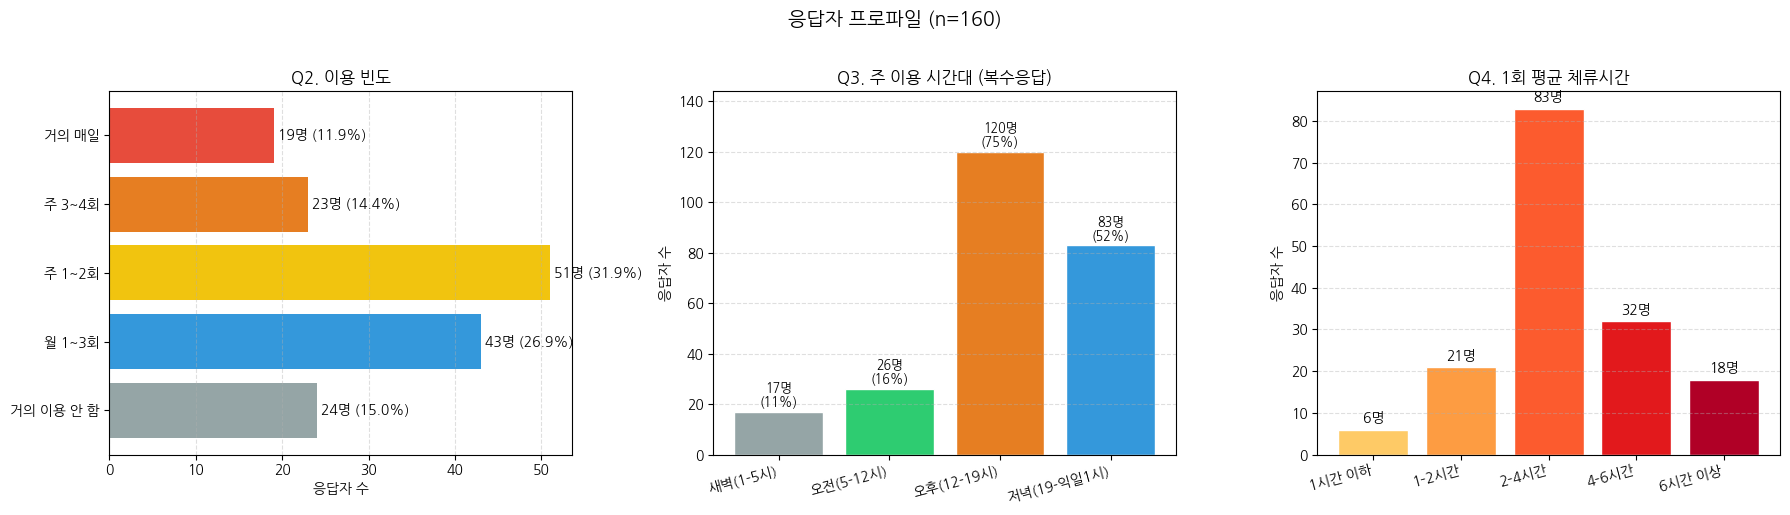


[프로파일 핵심]
  · 주 1회 이상 이용자: 93명 (58%)
  · 평균 체류시간(자기보고): 214분 ≈ 3.6시간
  · 가장 많이 답한 시간대  : 오후(12-19시) (120명)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) 이용 빈도
ax = axes[0]
freq_order = ['거의 매일', '주 3~4회', '주 1~2회', '월 1~3회', '거의 이용 안 함']
freq_cnt = survey['이용빈도'].value_counts().reindex(freq_order, fill_value=0)
bars = ax.barh(freq_cnt.index, freq_cnt.values,
               color=['#e74c3c','#e67e22','#f1c40f','#3498db','#95a5a6'])
for bar, v in zip(bars, freq_cnt.values):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2,
            f'{v}명 ({v/len(survey)*100:.1f}%)', va='center', fontsize=10)
ax.set_title('Q2. 이용 빈도', fontsize=12, fontweight='bold')
ax.set_xlabel('응답자 수')
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.4)

# (2) 주 이용 시간대 (다중선택)
ax2 = axes[1]
period_cnt = Counter()
for lst in survey['주이용시간대_매핑']:
    period_cnt.update(lst)
period_df = pd.Series(period_cnt).reindex(PERIOD_ORDER, fill_value=0)
bars = ax2.bar(period_df.index, period_df.values,
               color=['#95a5a6','#2ecc71','#e67e22','#3498db'],
               edgecolor='white')
for bar, v in zip(bars, period_df.values):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 1,
             f'{v}명\n({v/len(survey)*100:.0f}%)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Q3. 주 이용 시간대 (복수응답)', fontsize=12, fontweight='bold')
ax2.set_ylabel('응답자 수')
ax2.set_ylim(0, period_df.max() * 1.2)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
plt.setp(ax2.get_xticklabels(), rotation=15, ha='right')

# (3) 평균 체류 시간
ax3 = axes[2]
stay_order = ['1시간 이하', '1–2시간', '2–4시간', '4–6시간', '6시간 이상']
stay_cnt = survey['평균체류'].value_counts().reindex(stay_order, fill_value=0)
bars = ax3.bar(stay_cnt.index, stay_cnt.values,
               color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(stay_cnt))),
               edgecolor='white')
for bar, v in zip(bars, stay_cnt.values):
    ax3.text(bar.get_x() + bar.get_width()/2, v + 1,
             f'{v}명', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_title('Q4. 1회 평균 체류시간', fontsize=12, fontweight='bold')
ax3.set_ylabel('응답자 수')
ax3.grid(axis='y', linestyle='--', alpha=0.4)
plt.setp(ax3.get_xticklabels(), rotation=15, ha='right')

plt.suptitle('응답자 프로파일 (n=160)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 핵심 요약
weekly_users = survey['이용빈도'].isin(['거의 매일','주 3~4회','주 1~2회']).sum()
mean_stay = survey['평균체류_분'].mean()
print(f'\n[프로파일 핵심]')
print(f'  · 주 1회 이상 이용자: {weekly_users}명 ({weekly_users/len(survey)*100:.0f}%)')
print(f'  · 평균 체류시간(자기보고): {mean_stay:.0f}분 ≈ {mean_stay/60:.1f}시간')
print(f'  · 가장 많이 답한 시간대  : {period_df.idxmax()} ({period_df.max()}명)')

---
### B. 좌석·환경 선호 분석 — 행동 원인 규명


**분석 및 검증 과정**
- **Q7 선호 좌석 종류** 분석
  - 좌석 유형별 선호도 파악
  - 실측 좌석 유형별 점유율과 비교

- **Q8 선호 이유** 분석
  - 좌석 선택의 주요 동기 확인
  - 인기 좌석의 특성과 연결

- **Q9~Q12 환경 요인 중요도** 분석
  - 콘센트, 출입문 거리, 창가, 주변 시선 등 중요도 측정
  - 실측 분석에서 확인된 위치 요인(가장자리, 출입문 거리, 창문 거리)과 비교

- 설문 결과와 실측 결과를 결합하여
  - **좌석 편중의 원인** 규명
  - **환경 개선 필요 요소** 도출

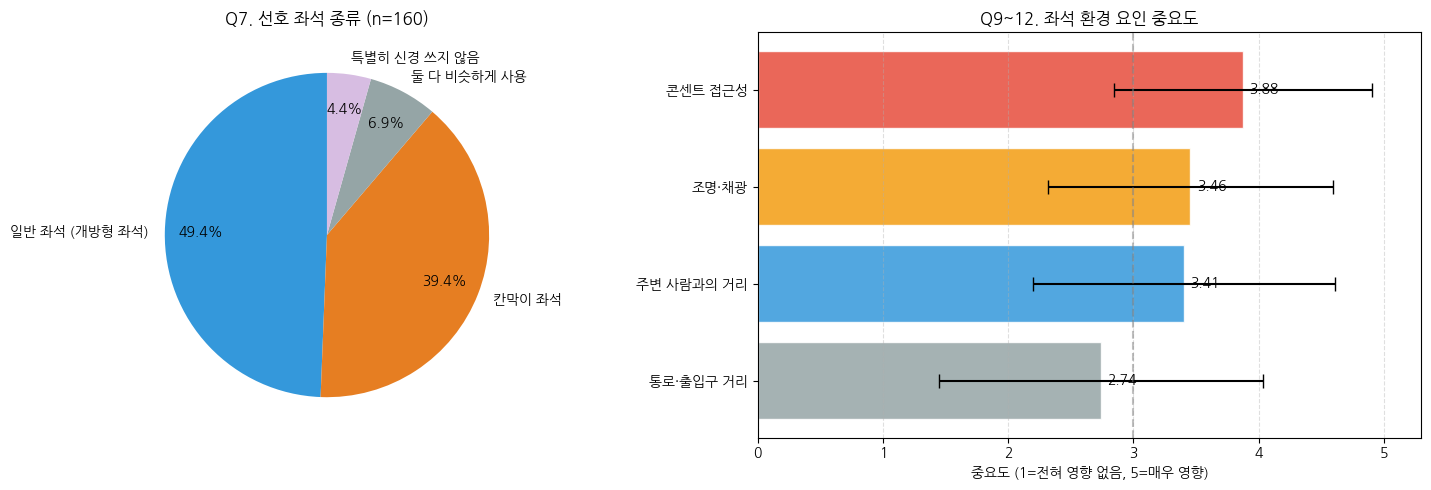


[B 핵심]
  · 가장 중요시되는 요인: 콘센트 접근성 (평균 3.88/5)
  · 가장 덜 중요시되는 요인: 통로·출입구 거리 (평균 2.74/5)
  → 단, B 결과(셀 36)에서 확인되었듯, 가장 덜 중요시한 "출입구 거리"가
     실측에서 유의한 동인으로 나타남 → "인식 ≠ 행동" 격차 확인.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (1) 선호 좌석 종류
ax = axes[0]
seat_pref = survey['선호좌석'].value_counts()
colors_p = ['#3498db', '#e67e22', '#95a5a6', '#d7bde2']
wedges, texts, autos = ax.pie(seat_pref.values, labels=seat_pref.index,
                              colors=colors_p, autopct='%1.1f%%',
                              startangle=90, pctdistance=0.78,
                              textprops={'fontsize': 10})
ax.set_title('Q7. 선호 좌석 종류 (n=160)', fontsize=12, fontweight='bold')

# (2) 환경 요인 중요도 (5점 척도 평균)
ax2 = axes[1]
env_cols = ['환경_콘센트', '환경_조명', '환경_주변사람거리', '환경_출입구거리']
env_label = ['콘센트 접근성', '조명·채광', '주변 사람과의 거리', '통로·출입구 거리']
env_mean  = survey[env_cols].mean().values
env_std   = survey[env_cols].std().values

bars = ax2.barh(env_label, env_mean, xerr=env_std,
                color=['#e74c3c','#f39c12','#3498db','#95a5a6'],
                edgecolor='white', capsize=5, alpha=0.85)
for bar, v in zip(bars, env_mean):
    ax2.text(v + 0.05, bar.get_y() + bar.get_height()/2,
             f'{v:.2f}', va='center', fontweight='bold')
ax2.set_xlim(0, 5.3)
ax2.set_xlabel('중요도 (1=전혀 영향 없음, 5=매우 영향)')
ax2.axvline(3, color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Q9~12. 좌석 환경 요인 중요도', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# 핵심 메시지
top_env = env_label[np.argmax(env_mean)]
low_env = env_label[np.argmin(env_mean)]
print(f'\n[B 핵심]')
print(f'  · 가장 중요시되는 요인: {top_env} (평균 {max(env_mean):.2f}/5)')
print(f'  · 가장 덜 중요시되는 요인: {low_env} (평균 {min(env_mean):.2f}/5)')
print(f'  → 단, B 결과(셀 36)에서 확인되었듯, 가장 덜 중요시한 "출입구 거리"가')
print(f'     실측에서 유의한 동인으로 나타남 → "인식 ≠ 행동" 격차 확인.')

=== 실측 좌석 type별 평균 점유율 ===
type
cubicle     30.0
normal      25.2
disabled     7.1


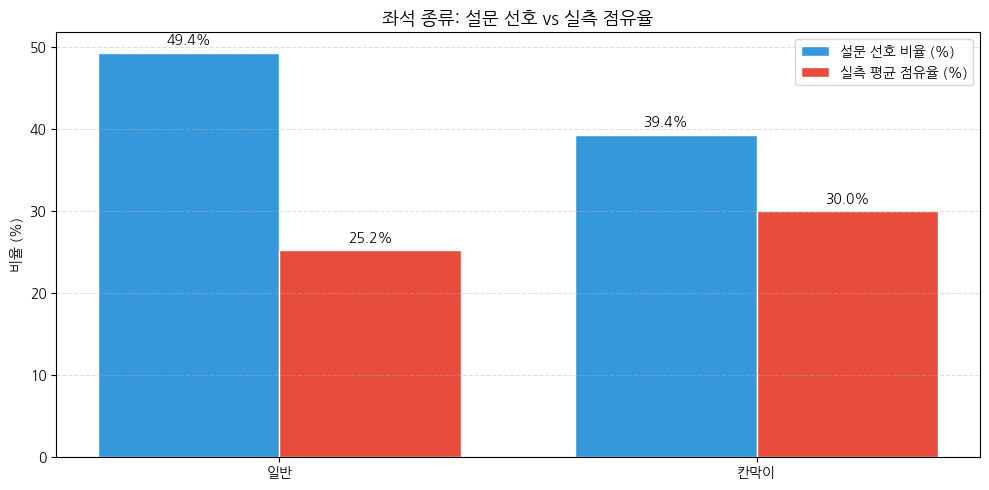

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 실측 데이터의 좌석 type별 점유율 확인
# df_final에서 활성 좌석만 추출하여 type 정보와 결합합니다.
layout_seats = pd.DataFrame([
    {'code_int': pd.to_numeric(el.get('id'), errors='coerce'),
     'type': el.get('type', 'normal')}
    for el in layout_data.get('elements', [])
    if el.get('category') == 'seat'
]).dropna(subset=['code_int'])

# df_final을 기준으로 점유율 계산 (code 컬럼 사용)
temp_df = df_final[df_final['isActive'] == True].copy()
temp_df['code_int'] = pd.to_numeric(temp_df['code'], errors='coerce')

df_with_type = temp_df.merge(layout_seats, on='code_int', how='left')
type_occ = df_with_type.groupby('type')['isOccupied'].mean().sort_values(ascending=False) * 100

print('=== 실측 좌석 type별 평균 점유율 ===')
print(type_occ.round(1).to_string())

# 설문 선호 vs 실측 점유율 비교 시각화
fig, ax = plt.subplots(figsize=(10, 5))
type_kor = {'normal':'일반', 'cubicle':'칸막이', 'disabled':'장애인석'}

pref_pct = {
    '일반':    (survey['선호좌석'].str.contains('일반')).sum() / len(survey) * 100,
    '칸막이': (survey['선호좌석'].str.contains('칸막이')).sum() / len(survey) * 100,
}
real_pct = {type_kor.get(k, k): v for k, v in type_occ.items() if type_kor.get(k, k) in pref_pct}

categories = list(pref_pct.keys())
x = np.arange(len(categories))
w = 0.38

bars1 = ax.bar(x - w/2, [pref_pct[c] for c in categories], w,
               label='설문 선호 비율 (%)', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + w/2, [real_pct.get(c, 0) for c in categories], w,
               label='실측 평균 점유율 (%)', color='#e74c3c', edgecolor='white')

for b in list(bars1) + list(bars2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{b.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('비율 (%)')
ax.set_title('좌석 종류: 설문 선호 vs 실측 점유율', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
### C. 자리비움 — "빈자리는 보이는데 왜 부족한가?"

**분석 질문**
- 점유된 좌석은 실제로 사용되고 있는가?
- 자리비움은 얼마나 자주, 얼마나 오래 발생하는가?
- 이용자들은 자리비움을 어떻게 인식하는가?

**분석 및 검증 과정**
- 자리비움 **시간 분포** 분석
- 자리비움 **발생 이유** 분석
- 자리비움 **허용 인식** 분석
- 실측의 "점유 상태"와 설문의 "실제 사용 상태"를 결합하여
  - **점유 ≠ 사용** 여부 확인
  - 좌석 부족 체감의 원인 규명

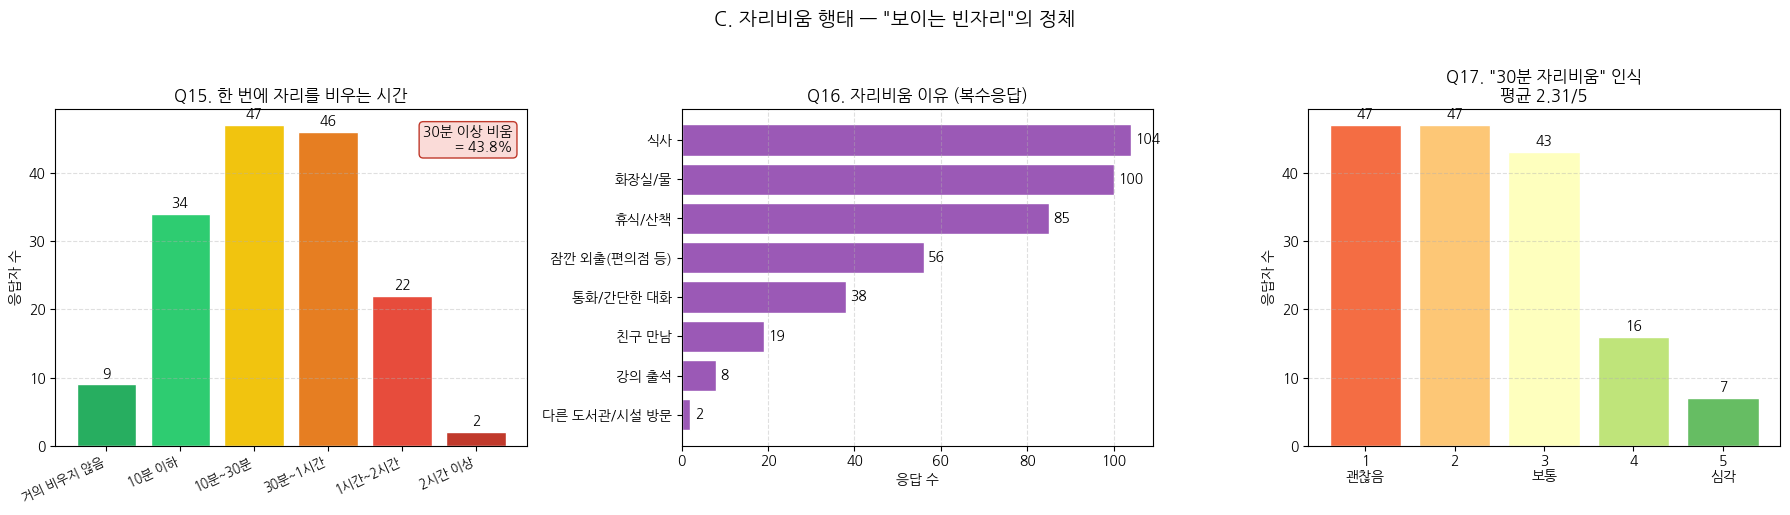


[발표의 핵심 메세지]
  · 한 번에 30분 이상 자리비우는 응답자: 43.8%
  · 자리비움을 "괜찮다"고 보는 비율 (1·2점): 58.8%
  · 자리비움 평균 인식 점수: 2.31/5 (낮을수록 관대)

  → 실측에서 "점유"로 잡힌 좌석 중 상당수가 실제로 사람이 없는 상태일 가능성.
  → 이것이 "빈자리는 보이는데 자리가 부족한" 현상의 직접적 원인.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) 자리비움 시간 분포
ax = axes[0]
absent_order = ['거의 비우지 않음', '10분 이하', '10분~30분',
                '30분~1시간', '1시간~2시간', '2시간 이상']
absent_cnt = survey['자리비움시간'].value_counts().reindex(absent_order, fill_value=0)
colors_ab = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#c0392b']
bars = ax.bar(absent_cnt.index, absent_cnt.values, color=colors_ab, edgecolor='white')
for bar, v in zip(bars, absent_cnt.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1,
            f'{v}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Q15. 한 번에 자리를 비우는 시간', fontsize=12, fontweight='bold')
ax.set_ylabel('응답자 수')
plt.setp(ax.get_xticklabels(), rotation=25, ha='right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# 30분 이상 비움 비율 강조
long_absent_pct = (absent_cnt[['30분~1시간','1시간~2시간','2시간 이상']].sum()
                   / len(survey) * 100)
ax.text(0.97, 0.95, f'30분 이상 비움\n= {long_absent_pct:.1f}%',
        transform=ax.transAxes, ha='right', va='top', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#fadbd8', edgecolor='#c0392b'))

# (2) 자리비움 이유 (다중선택)
ax2 = axes[1]
reason_cnt = Counter()
for lst in survey['자리비움이유_list']:
    reason_cnt.update(lst)
reason_top = pd.Series(reason_cnt).sort_values(ascending=False).head(8)
bars = ax2.barh(reason_top.index, reason_top.values,
                color='#9b59b6', edgecolor='white')
for bar, v in zip(bars, reason_top.values):
    ax2.text(v + 1, bar.get_y() + bar.get_height()/2,
             f'{v}', va='center', fontsize=10)
ax2.set_title('Q16. 자리비움 이유 (복수응답)', fontsize=12, fontweight='bold')
ax2.set_xlabel('응답 수')
ax2.invert_yaxis()
ax2.grid(axis='x', linestyle='--', alpha=0.4)

# (3) 30분 자리비움 인식 (5점 척도)
ax3 = axes[2]
percep_cnt = survey['자리비움인식'].value_counts().sort_index()
colors_pc = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(percep_cnt)))
bars = ax3.bar(percep_cnt.index, percep_cnt.values, color=colors_pc, edgecolor='white')
for bar, v in zip(bars, percep_cnt.values):
    ax3.text(bar.get_x() + bar.get_width()/2, v + 1,
             f'{v}', ha='center', fontsize=10, fontweight='bold')
ax3.set_xticks([1,2,3,4,5])
ax3.set_xticklabels(['1\n괜찮음', '2', '3\n보통', '4', '5\n심각'])
ax3.set_title(f'Q17. "30분 자리비움" 인식\n평균 {survey["자리비움인식"].mean():.2f}/5',
              fontsize=12, fontweight='bold')
ax3.set_ylabel('응답자 수')
ax3.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('C. 자리비움 행태 — "보이는 빈자리"의 정체', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 핵심 메시지
print(f'\n[발표의 핵심 메세지]')
print(f'  · 한 번에 30분 이상 자리비우는 응답자: {long_absent_pct:.1f}%')
print(f'  · 자리비움을 "괜찮다"고 보는 비율 (1·2점): '
      f'{(survey["자리비움인식"] <= 2).sum() / len(survey) * 100:.1f}%')
print(f'  · 자리비움 평균 인식 점수: {survey["자리비움인식"].mean():.2f}/5 (낮을수록 관대)')
print(f'\n  → 실측에서 "점유"로 잡힌 좌석 중 상당수가 실제로 사람이 없는 상태일 가능성.')
print(f'  → 이것이 "빈자리는 보이는데 자리가 부족한" 현상의 직접적 원인.')

---
### D. 시스템 만족도 및 개선안 — 정책 근거 도출

**분석 질문**
- 이용자들은 현재 좌석 시스템에 얼마나 만족하는가?
- 이용자가 체감하는 주요 불편 사항은 무엇인가?
- 이용자가 우선적으로 원하는 개선 정책은 무엇인가?

**분석 및 검증 과정**
- **시스템 만족도(Q19)** 분석
- **주요 불편 사항(Q20)** 분석
- **자동 반납 적정시간(Q21)** 분석
- **개선안 우선순위(Q22)** 분석
  - **가중점수**(1순위×3 + 2순위×2 + 3순위×1) 산출
- 결과를 종합하여
  - **이용자 수요 기반 정책 우선순위** 도출
  - **자동 반납 정책의 구체적 기준** 마련

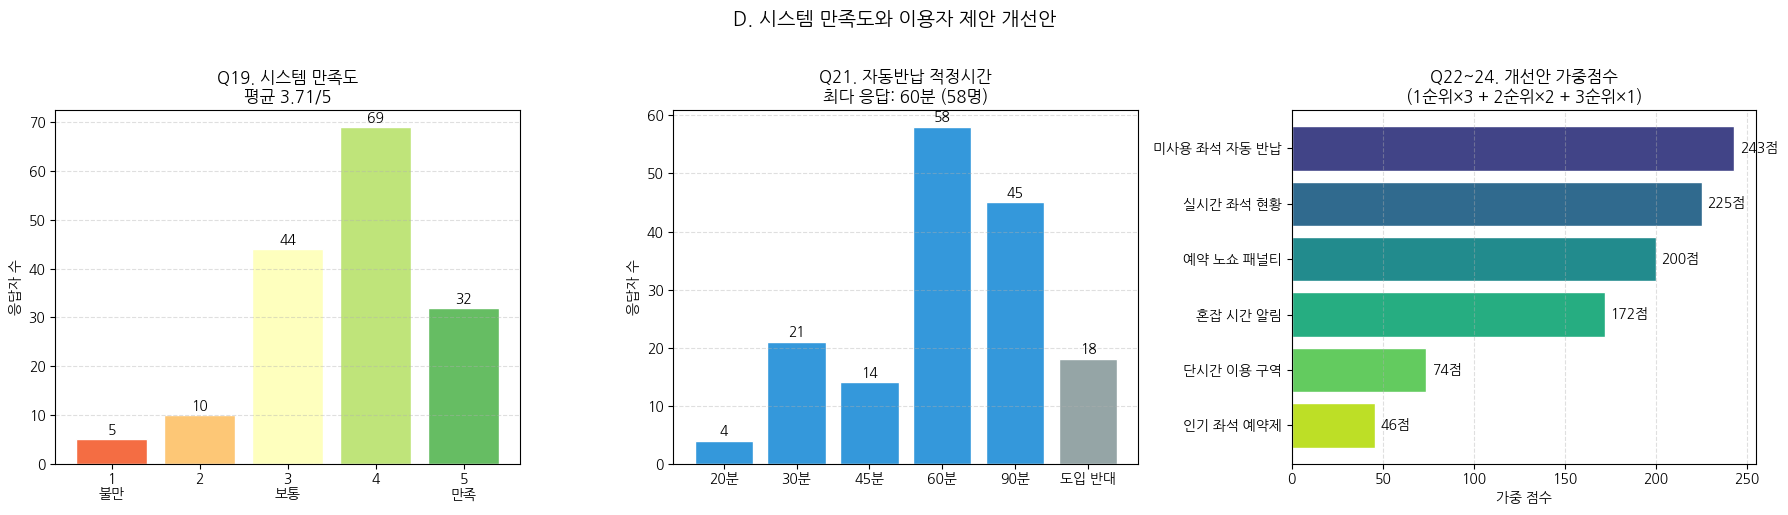


[D 핵심 — 정책 제안 슬라이드의 근거]
  · 시스템 만족도 평균   : 3.71/5
  · 자동반납 적정시간 최빈값 : 60분
  · 자동반납 평균 적정시간   : 62분
  · 가중점수 Top 3 개선안:
      1위: 미사용 좌석 자동 반납 (243점)
      2위: 실시간 좌석 현황 (225점)
      3위: 예약 노쇼 패널티 (200점)
  · 시스템 불편점 Top 3:
      1위: 예약 후 노쇼 (77명)
      2위: 딱히 없음 (39명)
      3위: 자리비움 시 자동 반납이 안 됨 (37명)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) 시스템 만족도 5점 + 시스템 불편점
ax = axes[0]
sat_cnt = survey['시스템만족'].value_counts().sort_index()
colors_s = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(sat_cnt)))
bars = ax.bar(sat_cnt.index, sat_cnt.values, color=colors_s, edgecolor='white')
for bar, v in zip(bars, sat_cnt.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1,
            f'{v}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks([1,2,3,4,5])
ax.set_xticklabels(['1\n불만', '2', '3\n보통', '4', '5\n만족'])
ax.set_title(f'Q19. 시스템 만족도\n평균 {survey["시스템만족"].mean():.2f}/5',
             fontsize=12, fontweight='bold')
ax.set_ylabel('응답자 수')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# (2) 자동반납 적정시간
ax2 = axes[1]
ret_order = ['20분', '30분', '45분', '60분', '90분', '도입 반대']
ret_cnt = survey['자동반납적정시간'].value_counts().reindex(ret_order, fill_value=0)
colors_r = ['#3498db']*5 + ['#95a5a6']
bars = ax2.bar(ret_cnt.index, ret_cnt.values, color=colors_r, edgecolor='white')
for bar, v in zip(bars, ret_cnt.values):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 1,
             f'{v}', ha='center', fontsize=10, fontweight='bold')
# 최빈값 강조
top_ret = ret_cnt.idxmax()
ax2.set_title(f'Q21. 자동반납 적정시간\n최다 응답: {top_ret} ({ret_cnt.max()}명)',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('응답자 수')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# (3) 개선 아이디어 가중점수 (1순위×3 + 2순위×2 + 3순위×1)
ax3 = axes[2]
score = Counter()
for r, w in [('개선1순위', 3), ('개선2순위', 2), ('개선3순위', 1)]:
    for v in survey[r].dropna():
        score[v] += w
score_s = pd.Series(score).sort_values(ascending=False)

colors_imp = plt.cm.viridis(np.linspace(0.2, 0.9, len(score_s)))
bars = ax3.barh(score_s.index, score_s.values, color=colors_imp, edgecolor='white')
for bar, v in zip(bars, score_s.values):
    ax3.text(v + 3, bar.get_y() + bar.get_height()/2,
             f'{int(v)}점', va='center', fontsize=10, fontweight='bold')
ax3.set_title('Q22~24. 개선안 가중점수\n(1순위×3 + 2순위×2 + 3순위×1)',
              fontsize=12, fontweight='bold')
ax3.set_xlabel('가중 점수')
ax3.invert_yaxis()
ax3.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('D. 시스템 만족도와 이용자 제안 개선안', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 핵심 요약
print(f'\n[D 핵심 — 정책 제안 슬라이드의 근거]')
print(f'  · 시스템 만족도 평균   : {survey["시스템만족"].mean():.2f}/5')
print(f'  · 자동반납 적정시간 최빈값 : {top_ret}')
print(f'  · 자동반납 평균 적정시간   : {survey["자동반납_분"].mean():.0f}분')
print(f'  · 가중점수 Top 3 개선안:')
for i, (name, sc) in enumerate(score_s.head(3).items(), 1):
    print(f'      {i}위: {name} ({int(sc)}점)')
print(f'  · 시스템 불편점 Top 3:')
dis_cnt = Counter()
for lst in survey['시스템불편점_list']: dis_cnt.update(lst)
for i, (name, c) in enumerate(pd.Series(dis_cnt).sort_values(ascending=False).head(3).items(), 1):
    print(f'      {i}위: {name} ({c}명)')

---
## 실측 + 설문 데이터 결합 해석

| 실측 데이터가 보여준 것 | 설문이 설명해준 원인·정책 근거 |
|---|---|
| **[A] 좌석 이용 편중**: χ² = 170,293.6 (p≈0), Gini = 0.268 → 특정 좌석에 이용 집중 | **[설문 B]** 이용자는 콘센트를 가장 중요하게 인식(3.88/5)하지만, 실제로는 모든 좌석에 동일하게 제공됨 → 좌석 편중은 시설 부족이 아니라 **공간 환경·위치 선호 문제**임을 확인 |
| **[B] 위치 요인 검증**: 가장자리 점수(ρ=0.45), 출입문 거리(ρ=0.28), 창문 거리(ρ=-0.22) 모두 유의 → 위치가 좌석 선택을 결정 | **[설문 B]** 이용자가 중요하게 생각하는 요소 중 **시선·주변 환경 관련 선호**가 확인됨 → 출입문 인근 저선호 좌석은 단순 증설보다 **시선 차단, 환경 보완**이 효과적이라는 근거 제공 |
| 실측은 좌석의 **점유 여부**만 확인 가능 | **[설문 C]** 30분 이상 자리비움 43.8%, 자리비움 허용 인식 58.8% → **점유 상태와 실제 사용 상태의 차이**를 확인. 빈자리가 보이는데도 예약이 불가능한 현상의 직접적 설명 |
| 시스템상으로는 좌석 회전이 발생해야 함 | **[설문 D]** 자동 반납 적정시간 최다 응답 60분(36.2%), 개선 우선순위 1위 '미사용 좌석 자동 반납' → 이용자가 체감하는 문제와 정책 수요를 직접 확인. **자동 반납 강화 정책의 구체적 근거** 제공 |

---

### 핵심 결과

#### ① 좌석 편중의 원인 = 시설 부족보다 공간 환경
- 콘센트는 모든 좌석에 존재
- 따라서 좌석 편중은 콘센트 부족 때문이 아님
- 실제로는 위치·시선·주변 환경이 좌석 선택을 결정

→ **출입문 인근 저선호 구역 환경 개선 필요**

#### ② 자리비움(노쇼) 좌석 "점유 ≠ 사용" 문제 존재
- 실측 데이터는 점유만 기록
- 설문에서는 장시간 자리비움이 빈번하게 발생
- 이용자 다수가 이를 크게 문제로 인식하지 않음

→ **실제 사용되지 않는 좌석이 점유 상태로 유지될 가능성 확인**

#### ③ 도서관 좌석 효율화 정책의 구체화
- 문제: 좌석 부족 자체보다 비효율적 점유
- 근거: 자리비움 43.8%, 자동 반납 선호 다수
- 이용자 요구: 미사용 좌석 자동 회수

→ **자동 반납 시간 단축(예: 60분)** 이 가장 직접적인 개선안

---

### 결론

설문은 실측 결과를 단순 비교·보완한 것이 아니라,

- **좌석 편중의 원인(공간 환경 선호)**
- **빈자리가 보이는데도 이용하지 못하는 원인(자리비움)**
- **어떤 정책이 필요한지(자동 반납·환경 개선)**

를 설명하여 **행동 데이터의 원인을 규명하고 정책의 구체성을 제공한다.**

---
## 최종 결론

### 데이터 분석 종합


#### A. 좌석 이용 편중

- 좌석 이용은 균등하지 않았으며 특정 좌석에 집중되는 경향이 나타났다.
- 카이제곱 검정 결과 좌석별 이용 빈도 차이는 통계적으로 유의했다.(p < .001)
- Gini 계수 0.268로 중간 수준의 편중이 확인되었고, 과이용 좌석(171석)과 저이용 좌석(275석)이 뚜렷하게 구분되었다.
- 좌석번호와 점유율의 관계는 없었다(ρ = 0.005).

→ **좌석 이용 편중은 번호가 아니라 위치·환경 요인에 의해 발생한다.**

---
#### B. 좌석과 공간 위치 요인

- 출입문에서 멀고, 창문에 가깝고, 가장자리에 위치한 좌석일수록 높은 점유율을 보였다.
- 특히 가장자리 점수(ρ=0.45)가 가장 강한 영향 요인으로 확인되어 이용자들은 중앙부보다 벽면·외곽 좌석을 선호하는 경향을 보였다.
- 반면 기둥 위치는 좌석 선호도에 유의한 영향을 주지 않았다.

→ **좌석 선택은 시설 차이보다 공간적 안정감과 위치적 특성에 의해 결정되는 것으로 나타났다.**

---
#### C. 시간대별 점유율 차이

- Kruskal-Wallis 검정 결과, 시간대에 따라 점유율이 유의하게 달라졌으며(p < .001), 오전(8.6%)보다 오후(34.8%)와 저녁(38.1%)에 이용이 집중되었다.
- 특히 상위 30개 인기 좌석은 오후에 이미 평균 80% 수준까지 점유되어 선호 좌석의 조기 포화 현상이 나타났다.
- 전체 점유율은 저녁에 가장 높았지만, 인기 좌석 경쟁은 오후부터 본격적으로 시작되었다.

→ **좌석 부족은 단순한 좌석 수의 문제가 아니라, 특정 시간대에 선호 좌석으로 이용이 집중되면서 발생하는 체감적 혼잡 현상으로 해석된다.**

---
#### D. 시험 직전·시험기간·평시 비교

- Kruskal-Wallis 검정 결과, 시험 직전과 시험 기간의 평균 점유율은 평시보다 약 2.6~2.9배 높게 나타났으며, 기간별 이용 차이는 통계적으로 유의했다(p < .001).
- 시험 기간에는 저녁 시간대의 높은 점유율이 장시간 유지되었고, 동일 좌석의 반복 예약도 증가하였다.
- 이는 단순히 이용자가 많아진 현상보다 기존 이용자의 체류시간과 좌석 점유 시간이 증가한 결과로 해석된다.

→ **시험 기간의 좌석 부족은 이용 수요 증가와 함께 장시간 점유가 결합되어 발생하며, 좌석 회전율 관리의 필요성을 시사한다.**




### 설문조사 기반 정책 제안

실측 분석은 좌석 부족 현상의 원인을 보여주었고, 설문조사는 **어떤 정책을, 어느 수준으로 시행해야 하는지**에 대한 구체적 기준을 제공한다.

---
#### ① 자동 반납 강화 — 미사용 좌석 회수

- **문제**
  - 응답자의 43.8%가 한 번에 30분 이상 자리를 비움
  - 58.8%는 이를 문제로 인식하지 않음
  - 점유 상태와 실제 사용 상태 간 격차 존재

- **설문 근거**
  - 자동 반납 적정시간: **60분(36.2%) > 90분(28.1%)**
  - 개선 우선순위 1위: **미사용 좌석 자동 반납 (243점)**

- **정책 제안**
  - 현재 **90분 무사용 자동 반납 → 60분으로 단축**
  - 특히 시험기간에는 좌석 회전율 확보를 위해 우선 적용 검토

---

#### ② 저이용 좌석 환경 개선 — 위치 편중 완화

- **문제**
  - 출입문 인근·중앙 좌석의 지속적인 저이용
  - 좌석 부족보다 특정 좌석으로의 이용 집중이 핵심 문제

- **설문 근거**
  - 콘센트 중요도는 높게 평가되었으나(3.88/5), 이미 전 좌석에 동일 제공
  - 시설 증설보다 환경 개선이 더 효과적

- **정책 제안**
  - **출입문 인근 저이용 좌석에 파티션, 가벽, 식물 등 시선 차단 요소** 설치
  - 신규 좌석 증설보다 **기존 좌석 활용률 개선**에 집중

---

#### ③ 노쇼 관리 — 예약 효율 향상

- **문제**

  - 시스템 불편사항 1위: **예약 후 노쇼(48.1%)**
  - 현재 게이트는 입·출입 구분 없이 모두 IN으로 처리
  - 예약만 유지된 채 실제 사용되지 않는 좌석 발생

- **설문 근거**

  - 실시간 좌석 현황 제공: **225점**
  - 노쇼 패널티 도입: **200점**

- **정책 제안**

  - 노쇼를 **게이트 인으로 속인 후 노쇼**와 **실제 게이트 인 후 노쇼**로 구분
  - 데이터 기반 관리가 가능한 **게이트 인 속인 후 노쇼**에 집중

  - **연속 IN 차단 알고리즘 도입**
    - OUT → IN : 정상
    - IN → IN (15분 이상 간격) : 비정상 로그
    - 반복 발생 : 경고 → 좌석 자동 반납 → 예약 제한



---

### 도서관 이용 효율화 정책

1. **자동 반납 시간 단축(90분 → 60분)** 을 통한 미사용 좌석 회수,
2. **출입문 인근 저이용 좌석의 환경 개선**을 통한 좌석 편중 완화
3. **연속 IN 차단 알고리즘을 통한 노쇼 관리**로 예약 시스템 효율화

를 제안한다. 모두 **추가 좌석 설치 없이 기존 자원의 활용도를 높이는 방안**이다.



---
## 마무리

본 연구는 열람실 좌석 부족 문제가 단순한 좌석 수 부족이 아니라 **좌석 이용 편중, 특정 시간대 이용 집중, 시험기간 장시간 점유**에 의해 발생한다는 점을 데이터로 확인하였다.

분석 결과, 좌석 이용은 균등하지 않았으며
**특정 위치의 좌석**에 이용이 집중되었다. 또한 이용자들은 **출입문에서 멀고 가장자리에 위치한 좌석**을 선호하는 경향을 보였으며, **오후**부터 인기 좌석이 빠르게 포화되는 현상이 나타났다. **시험기간**에는 평균 점유율이 평시 대비 약 2.6~2.9배 증가하였고, 동일 좌석의 반복 이용이 늘어나면서 좌석 회전율 저하 가능성도 확인되었다.

이러한 결과는 현재의 좌석 부족 문제가 절대적인 좌석 수의 부족보다는 **좌석 이용의 불균형과 특정 시기의 이용 집중**에서 비롯된다는 점을 시사한다. 따라서 좌석 증설보다 **기존 좌석의 활용도를 높이는 운영 정책이 더 효과적인 대안**이 될 수 있다.

설문조사는 이러한 이용 패턴의 원인을 보완적으로 설명하고, 자동 반납 시간, 환경 개선 대상, 노쇼 관리 등 정책의 구체적인 시행 기준을 설정하는 데 활용하였다.

---
### 의의
* **실측 데이터와 설문조사를 결합**하여 열람실 이용 행태를 종합적으로 분석하였다.
* 실측 데이터를 활용하여 열람실 좌석 이용 패턴을 **정량적으로 분석**하였다.
* 좌석 이용 편중, 시간대별 혼잡, 시험기간 이용 집중 현상을 **통계적으로 검증**하였다.
* 실측 데이터로 확인된 좌석 이용 패턴의 **원인을 설문조사를 통해 설명**하였다.
* **이용자의 직접 응답**을 바탕으로 자동 반납 시간, 환경 개선 대상, 노쇼 관리 방식 등 **구체적인 운영 정책 기준**을 도출하였다.
* 좌석 부족 문제를 좌석 수 부족이 아닌 **운영 효율성 관점**에서 해석하였다.
* 새로운 시설 확충보다 **기존 좌석 운영 개선**을 통한 효율화 가능성을 제시하였다.

---
### 한계

* 본 연구는 시스템에 기록된 데이터를 기준으로 분석하였으며, 기본적으로 **'게이트 IN = 실제 이용'** 을 **전제**로 한다.
* 따라서 점유율, 이용률, 회전율 등의 분석 결과 역시 현재 시스템 기록을 기반으로 해석하였다.
* **노쇼 문제와 관련하여 연속 IN 차단 알고리즘을 제안**하였으나, 이는 입·출입 로그 데이터와 열람실 이용 데이터를 종합하여 도출한 정책 아이디어이며 **본 연구 데이터로만 직접 검증한 결과는 아니다.**
* 향후에는 입·출입 기록과 실제 좌석 사용 여부를 함께 수집하여 노쇼 규모와 시스템 운영 효과를 추가적으로 검증할 필요가 있다.
